<a href="https://colab.research.google.com/github/TienNguyen0712/customer-churn-data-mining/blob/main/notebooks/02_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **🎯 EDA Objective (Mục tiêu Khám phá dữ liệu)**


Mục tiêu của việc khám phá dữ liệu này là để tìm hiểu phân bố của các đặc trưng đồng thời cũng là cách để phát hiện các mối quan hệ đặc biệt giữa các đặc trưng với biên mục tiêu **Churn** cụ thể như sau:

- Phân bố của biến mục tiêu Churn
- Yếu tố nào có khả năng ảnh hưởng mạnh nhất để 1 khách hàng rời bỏ
- So sánh các đặc điểm của khách hàng rời bỏ và không tời bỏ
- Mối quan hệ trực quan tới khả năng rời bỏ

Lựa chọn dãy màu sẽ sử dụng trong suốt quá trình Khám phá dữ liệu

In [263]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'serif'
plt.rcParams["figure.facecolor"] = "#fafafa"
plt.rcParams["axes.facecolor"] = "#fafafa"

In [264]:
telco = pd.read_csv('telco_customer.csv')

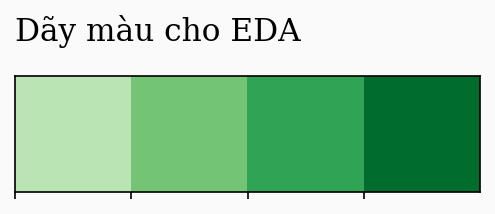

In [265]:
# Palette
palette = ["#bae4b3", "#74c476", "#31a354", "#006d2c"]
sns.palplot(palette)

plt.title("Dãy màu cho EDA",loc='left',fontsize=15,y=1.2)
plt.show()

## **📈 Target Variable Distribution - Churn (Phân bố biến mục tiêu - Churn)**


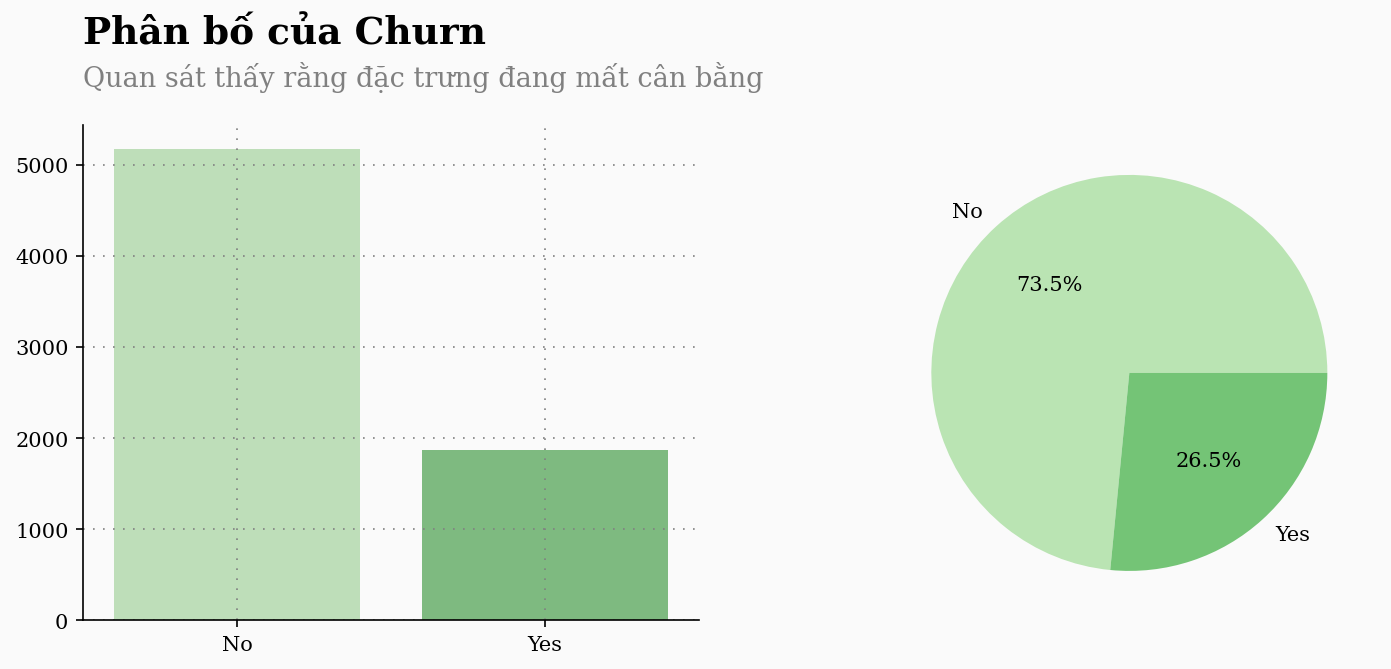

In [266]:
fig = plt.figure(figsize=(18,15))
gs = fig.add_gridspec(3, 3)
gs.update(wspace=0.2, hspace=0.25)
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])

for s in ["right", "top"]:
    ax0.spines[s].set_visible(False)


sns.countplot(ax=ax0, x=telco["Churn"], palette=palette)

Xstart, Xend = ax0.get_xlim()
Ystart, Yend = ax0.get_ylim()
ax0.set_ylim([0,Yend])
ax0.text(Xstart,Yend+(Yend*0.15), "Phân bố của Churn", fontsize=18, ha="left", va="bottom", weight="bold")
ax0.text(Xstart,Yend+(Yend*0.13), "Quan sát thấy rằng đặc trưng đang mất cân bằng", color="gray",
fontsize=13, ha="left", va="top")


size = telco["Churn"].value_counts() / telco.shape[0] * 100 # Tính tỷ lệ trong churn

plt.pie(size, labels=size.index, colors=palette, autopct='%1.1f%%')

ax0.set_xlabel("")
ax0.set_ylabel("")

ax0.grid(which='major', axis='x', zorder=0, color='gray', linestyle=':', dashes=(1,5))
ax0.grid(color='gray', linestyle=':', axis='y', zorder=0,  dashes=(1,5))

plt.show()

**Nhận xét**

Đặc trưng mục tiêu **Churn** có khả năng bị mất cân bằng
- Cột No cao hơn cột Yes
- Tỷ lệ No chiếm nhiều hơn cột Yes

Điều này là hiển nhiên trong dữ liệu thực tế bởi lẽ không phải dữ liệu lúc nào cũng hoàn hảo

## **👤 Personal Factors vs Churn (So sánh Churn và Không Churn theo các thống tin cá nhân)**




In [267]:
personals = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure']

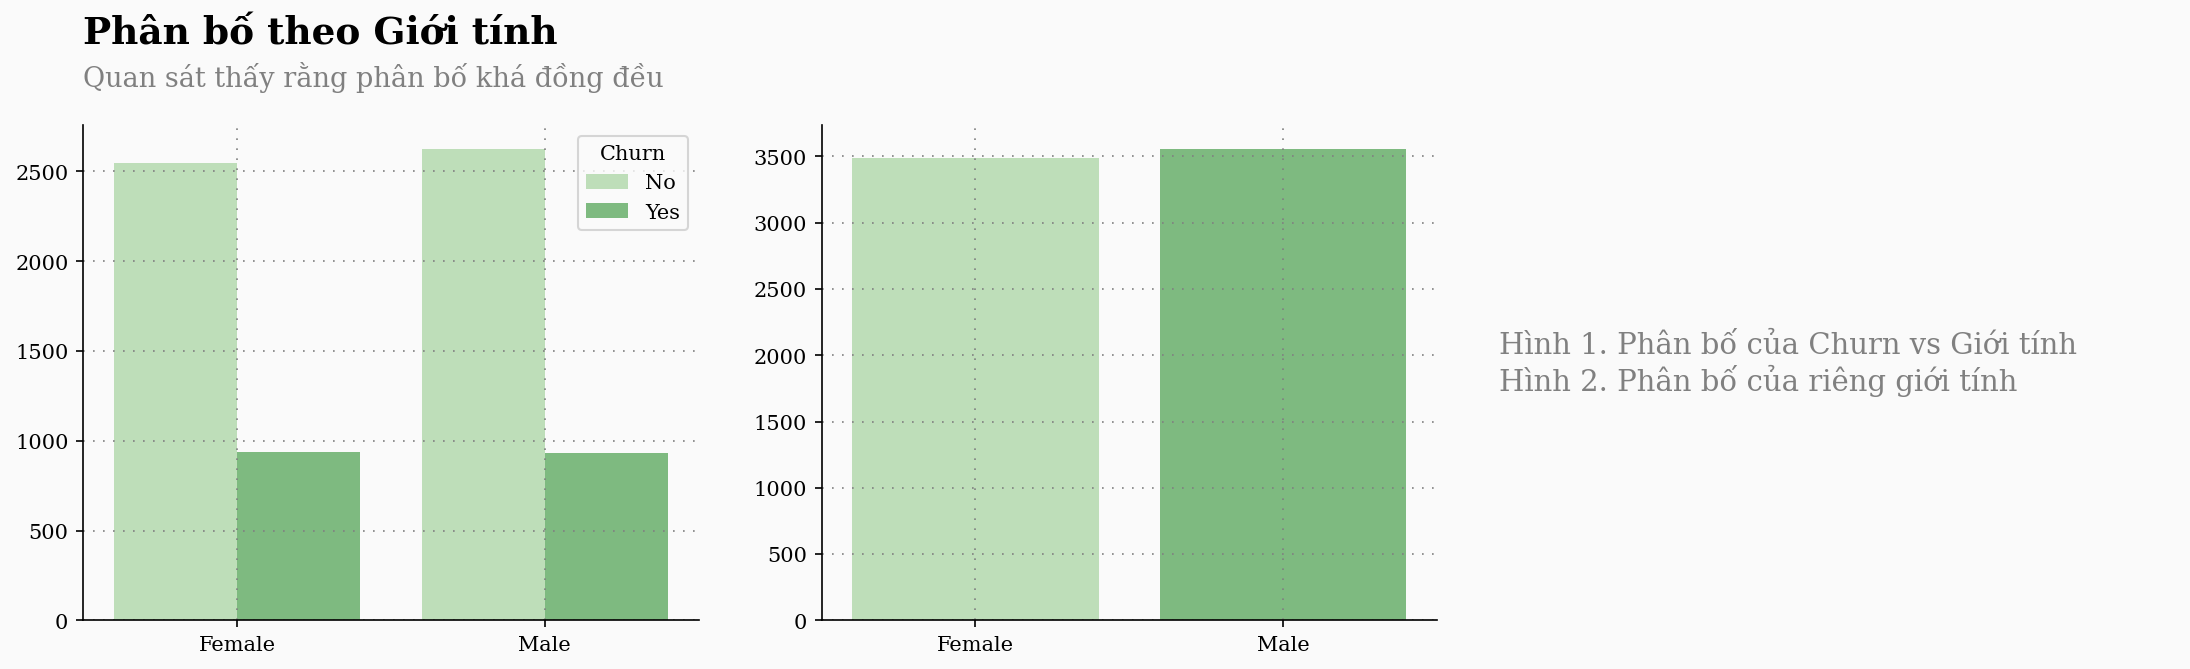

In [268]:
telco_personals = telco[personals]

fig = plt.figure(figsize=(18,15))
gs = fig.add_gridspec(3, 3)
gs.update(wspace=0.2, hspace=0.25)
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[0, 2])


for s in ["right", "top"]:
    ax0.spines[s].set_visible(False)
    ax1.spines[s].set_visible(False)



sns.countplot(ax=ax1, x=telco_personals['gender'], palette=palette)
sns.countplot(ax=ax0, x=telco_personals['gender'], hue=telco['Churn'], palette=palette)



Xstart, Xend = ax0.get_xlim()
Ystart, Yend = ax0.get_ylim()

ax0.set_ylim([0,Yend])
ax0.text(Xstart,Yend+(Yend*0.15), "Phân bố theo Giới tính", fontsize=18, ha="left", va="bottom", weight="bold")
ax0.text(Xstart,Yend+(Yend*0.13), "Quan sát thấy rằng phân bố khá đồng đều", color="gray",
fontsize=13, ha="left", va="top")

ax0.set_xlabel("")
ax0.set_ylabel("")
ax1.set_xlabel("")
ax1.set_ylabel("")

ax0.grid(which='major', axis='x', zorder=0, color='gray', linestyle=':', dashes=(1,5))
ax0.grid(color='gray', linestyle=':', axis='y', zorder=0,  dashes=(1,5))
ax1.grid(which='major', axis='x', zorder=0, color='gray', linestyle=':', dashes=(1,5))
ax1.grid(color='gray', linestyle=':', axis='y', zorder=0,  dashes=(1,5))


ax2.axis('off')  # Ẩn trục
ax2.text(-0.1, 0.4,
             "Hình 1. Phân bố của Churn vs Giới tính\n"
             "Hình 2. Phân bố của riêng giới tính\n",
             fontsize=14,  color="gray")

plt.show()

**Nhận xét**

Phân bố giới tính trong dữ liệu là cân bằng về nam và nữa. Nam vượt nữ một chút nhưng không phải là đáng kể. Tỷ lệ không rời bỏ của nam cũng nhiều hơn của nữ điều này là do tác động của cột giới tính nam nhiều hơn của nữ

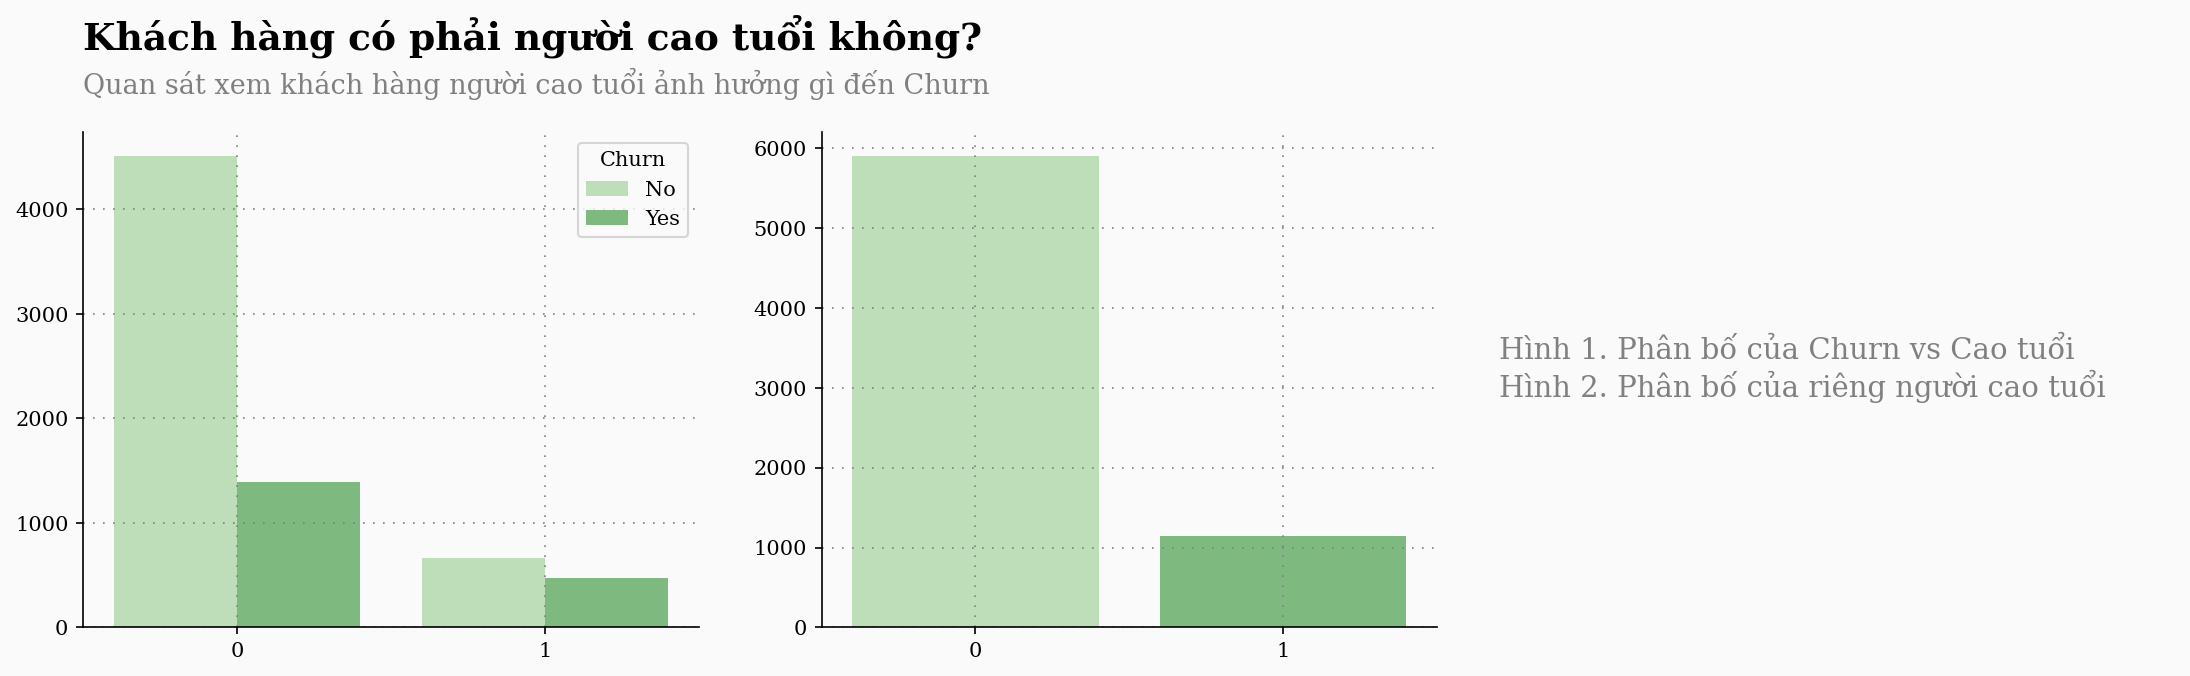

In [269]:
telco_personals = telco[personals]

fig = plt.figure(figsize=(18,15))
gs = fig.add_gridspec(3, 3)
gs.update(wspace=0.2, hspace=0.25)
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[0, 2])


for s in ["right", "top"]:
    ax0.spines[s].set_visible(False)
    ax1.spines[s].set_visible(False)



sns.countplot(ax=ax1, x=telco_personals['SeniorCitizen'], palette=palette)
sns.countplot(ax=ax0, x=telco_personals['SeniorCitizen'], hue=telco['Churn'], palette=palette)

Xstart, Xend = ax0.get_xlim()
Ystart, Yend = ax0.get_ylim()

ax0.set_ylim([0,Yend])
ax0.text(Xstart,Yend+(Yend*0.15), "Khách hàng có phải người cao tuổi không?", fontsize=18, ha="left", va="bottom", weight="bold")
ax0.text(Xstart,Yend+(Yend*0.13), "Quan sát xem khách hàng người cao tuổi ảnh hưởng gì đến Churn", color="gray",
fontsize=13, ha="left", va="top")

ax0.set_xlabel("")
ax0.set_ylabel("")
ax1.set_xlabel("")
ax1.set_ylabel("")

ax0.grid(which='major', axis='x', zorder=0, color='gray', linestyle=':', dashes=(1,5))
ax0.grid(color='gray', linestyle=':', axis='y', zorder=0,  dashes=(1,5))
ax1.grid(which='major', axis='x', zorder=0, color='gray', linestyle=':', dashes=(1,5))
ax1.grid(color='gray', linestyle=':', axis='y', zorder=0,  dashes=(1,5))


ax2.axis('off')  # Ẩn trục
ax2.text(-0.1, 0.4,
             "Hình 1. Phân bố của Churn vs Cao tuổi\n"
             "Hình 2. Phân bố của riêng người cao tuổi\n",
             fontsize=14,  color="gray")

plt.show()

**Nhận xét**

Người cao tuổi không chiếm nhiều trong bộ dữ liệu và tỷ lệ churn của người cao tuổi và người không cao tuổi đều giống nhau về mặt so sánh (không rời bỏ nhiều hơn rời bỏ)

Tuy nhiên, về chênh lệnh thì số người không rời bỏ chênh lệch nhiều hơn hẳn

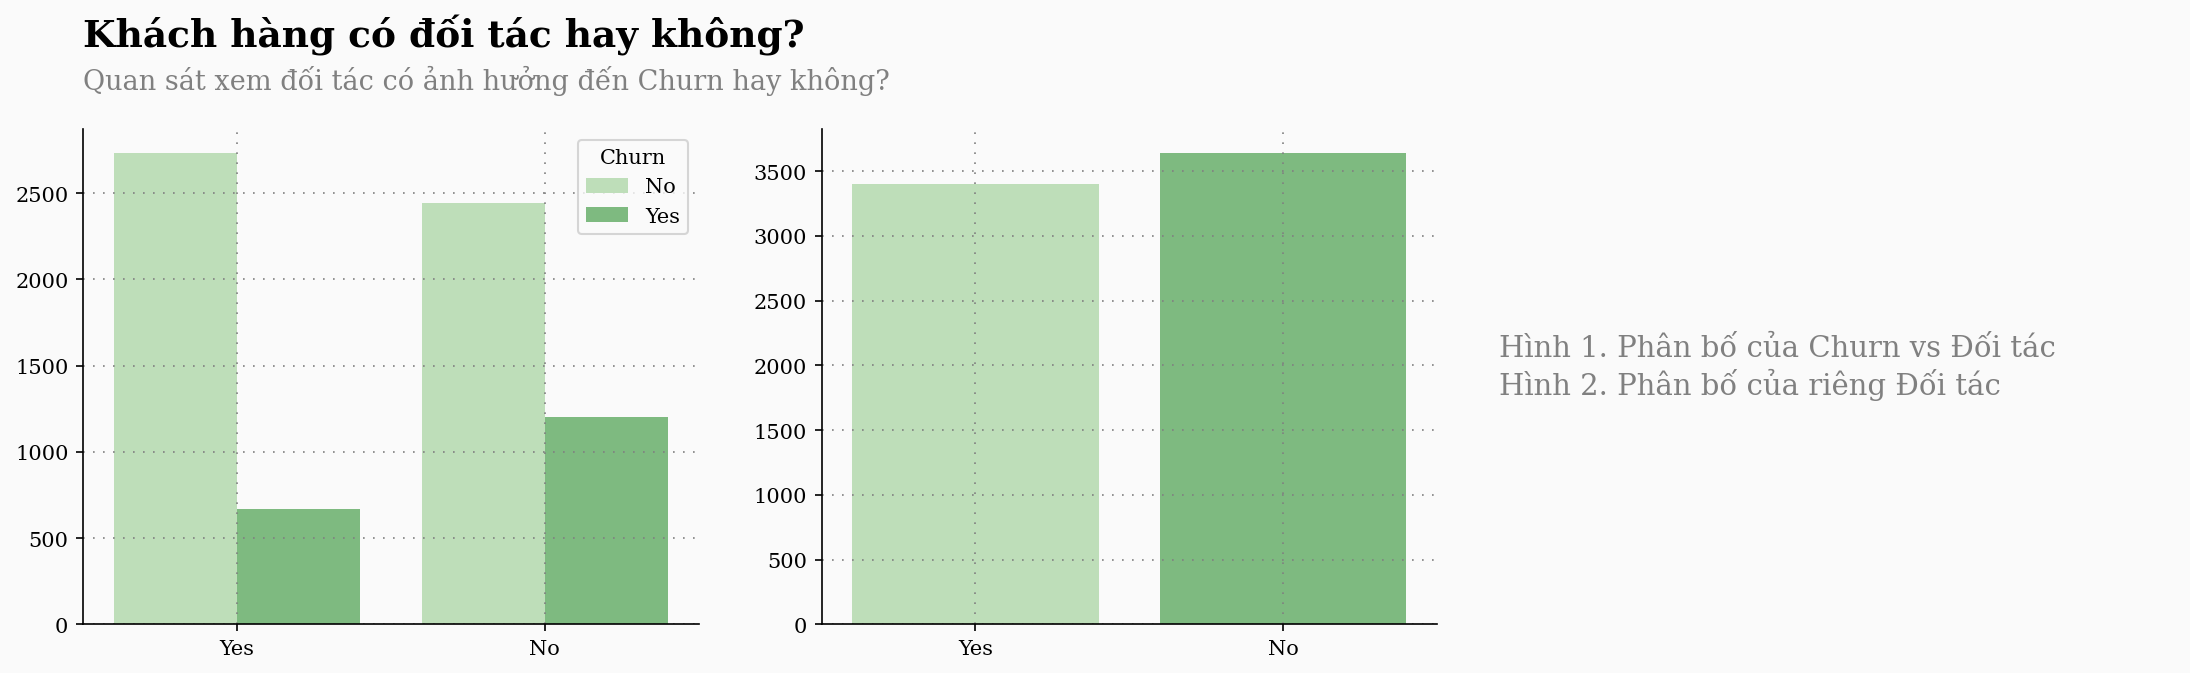

In [270]:
telco_personals = telco[personals]

fig = plt.figure(figsize=(18,15))
gs = fig.add_gridspec(3, 3)
gs.update(wspace=0.2, hspace=0.25)
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[0, 2])


for s in ["right", "top"]:
    ax0.spines[s].set_visible(False)
    ax1.spines[s].set_visible(False)



sns.countplot(ax=ax1, x=telco_personals['Partner'], palette=palette)
sns.countplot(ax=ax0, x=telco_personals['Partner'], hue=telco['Churn'], palette=palette)



Xstart, Xend = ax0.get_xlim()
Ystart, Yend = ax0.get_ylim()

ax0.set_ylim([0,Yend])
ax0.text(Xstart,Yend+(Yend*0.15), "Khách hàng có đối tác hay không?", fontsize=18, ha="left", va="bottom", weight="bold")
ax0.text(Xstart,Yend+(Yend*0.13), "Quan sát xem đối tác có ảnh hưởng đến Churn hay không?", color="gray",
fontsize=13, ha="left", va="top")

ax0.set_xlabel("")
ax0.set_ylabel("")
ax1.set_xlabel("")
ax1.set_ylabel("")

ax0.grid(which='major', axis='x', zorder=0, color='gray', linestyle=':', dashes=(1,5))
ax0.grid(color='gray', linestyle=':', axis='y', zorder=0,  dashes=(1,5))
ax1.grid(which='major', axis='x', zorder=0, color='gray', linestyle=':', dashes=(1,5))
ax1.grid(color='gray', linestyle=':', axis='y', zorder=0,  dashes=(1,5))


ax2.axis('off')  # Ẩn trục
ax2.text(-0.1, 0.4,
             "Hình 1. Phân bố của Churn vs Đối tác\n"
             "Hình 2. Phân bố của riêng Đối tác\n",
             fontsize=14,  color="gray")

plt.show()

**Nhận xét**

Phân bố khá giống với giới tinh, chúng đều cân bằng có hơn một chút ở người không có đối tác chiếm nhiều hơn

Tuy nhiên người không rời bỏ ở mẫu có đối tác lại nhiều hơn người không có đối tác và với người không có đối tác thì khả năng rời bỏ nhiều hơn người có đối tác

Điều này là đối lập với nhau

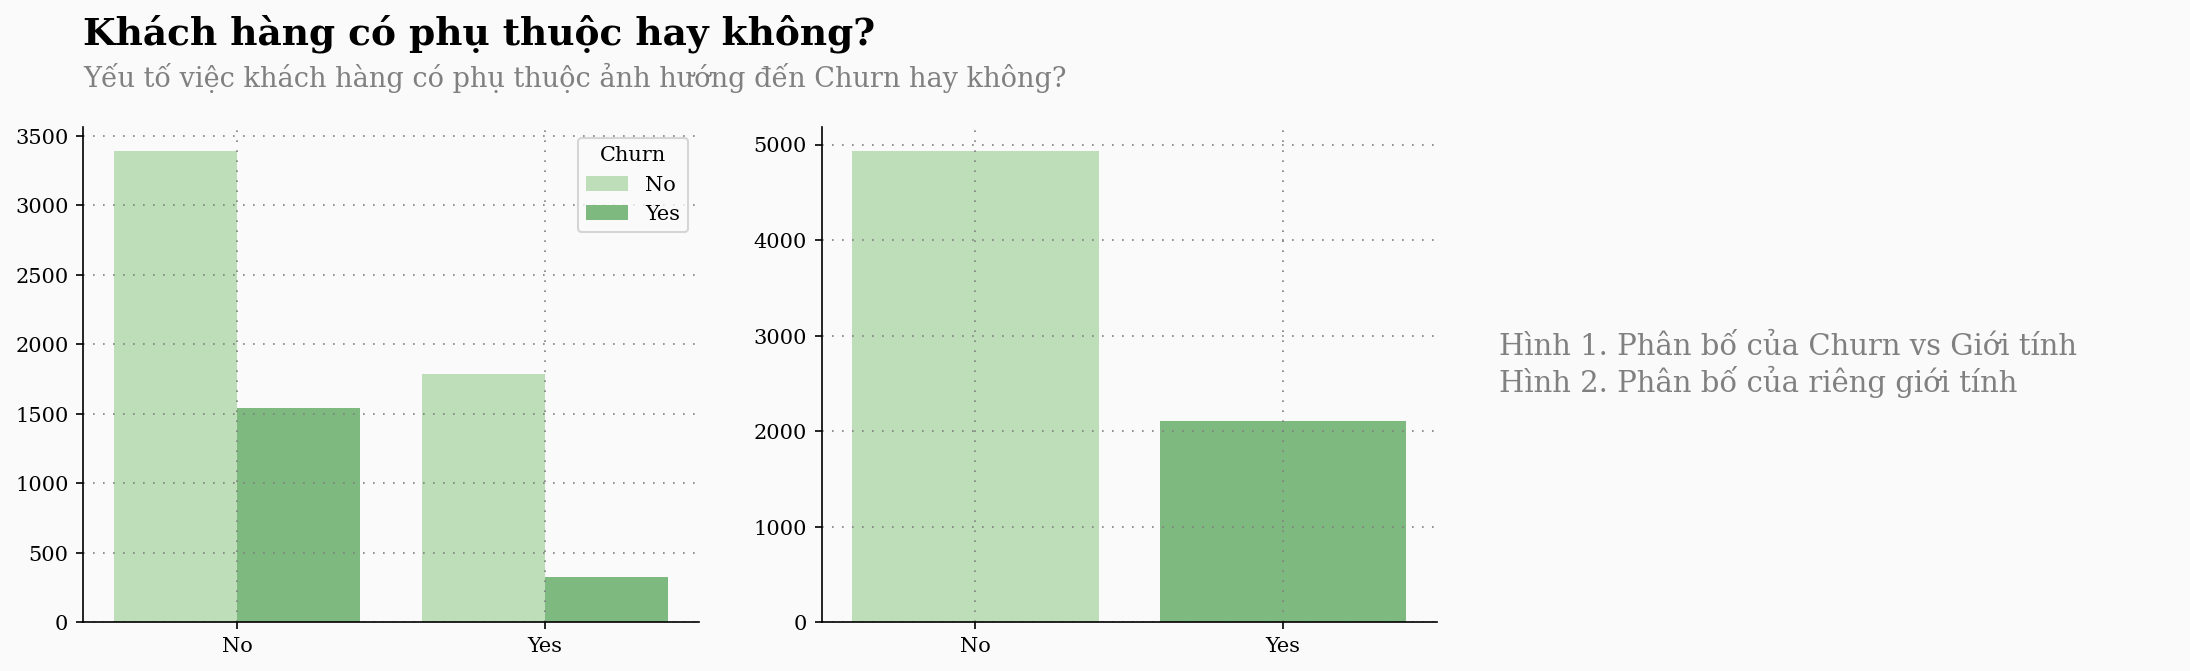

In [271]:
telco_personals = telco[personals]

fig = plt.figure(figsize=(18,15))
gs = fig.add_gridspec(3, 3)
gs.update(wspace=0.2, hspace=0.25)
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[0, 2])


for s in ["right", "top"]:
    ax0.spines[s].set_visible(False)
    ax1.spines[s].set_visible(False)



sns.countplot(ax=ax1, x=telco_personals['Dependents'], palette=palette)
sns.countplot(ax=ax0, x=telco_personals['Dependents'], hue=telco['Churn'], palette=palette)



Xstart, Xend = ax0.get_xlim()
Ystart, Yend = ax0.get_ylim()

ax0.set_ylim([0,Yend])
ax0.text(Xstart,Yend+(Yend*0.15), "Khách hàng có phụ thuộc hay không?", fontsize=18, ha="left", va="bottom", weight="bold")
ax0.text(Xstart,Yend+(Yend*0.13), "Yếu tố việc khách hàng có phụ thuộc ảnh hướng đến Churn hay không?", color="gray",
fontsize=13, ha="left", va="top")

ax0.set_xlabel("")
ax0.set_ylabel("")
ax1.set_xlabel("")
ax1.set_ylabel("")

ax0.grid(which='major', axis='x', zorder=0, color='gray', linestyle=':', dashes=(1,5))
ax0.grid(color='gray', linestyle=':', axis='y', zorder=0,  dashes=(1,5))
ax1.grid(which='major', axis='x', zorder=0, color='gray', linestyle=':', dashes=(1,5))
ax1.grid(color='gray', linestyle=':', axis='y', zorder=0,  dashes=(1,5))


ax2.axis('off')  # Ẩn trục
ax2.text(-0.1, 0.4,
             "Hình 1. Phân bố của Churn vs Giới tính\n"
             "Hình 2. Phân bố của riêng giới tính\n",
             fontsize=14,  color="gray")

plt.show()

**Nhận xét**

Người không phụ thuộc nhiều hơn người có phụ thuộc và tỷ lệ rời bỏ và không rời bỏ của hai mẫu này cũng không có gì khác biệt

Báo hiệu đây có thể là yếu tố không quyết định nhiều đến khả năng rời bỏ của khác hàng

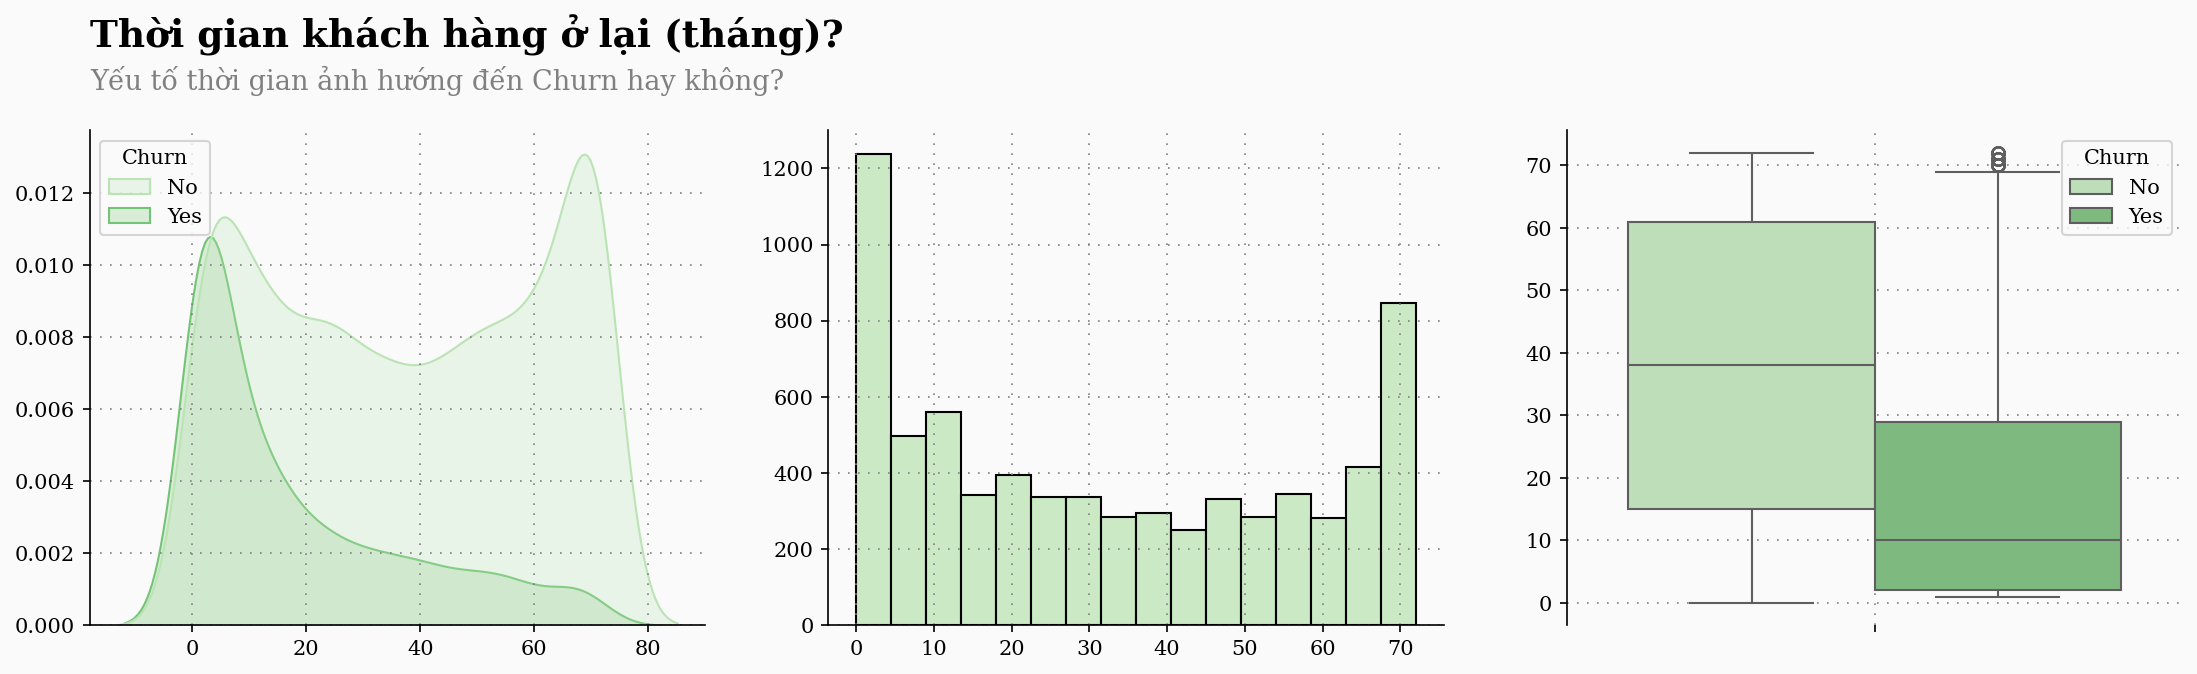

In [272]:
telco_personals = telco[personals]

fig = plt.figure(figsize=(18,15))
gs = fig.add_gridspec(3, 3)
gs.update(wspace=0.2, hspace=0.25)
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[0, 2])


for s in ["right", "top"]:
    ax0.spines[s].set_visible(False)
    ax1.spines[s].set_visible(False)

for s in ["right", "top", "bottom"]:
    ax2.spines[s].set_visible(False)

sns.kdeplot(ax=ax0, x=telco_personals['tenure'], hue=telco['Churn'], palette=palette, shade=True)
sns.histplot(ax=ax1, x=telco_personals['tenure'], color='#bae4b3')
sns.boxplot(ax=ax2, y=telco_personals['tenure'],hue=telco['Churn'], palette=palette)



Xstart, Xend = ax0.get_xlim()
Ystart, Yend = ax0.get_ylim()

ax0.set_ylim([0,Yend])
ax0.text(Xstart,Yend+(Yend*0.15), "Thời gian khách hàng ở lại (tháng)?", fontsize=18, ha="left", va="bottom", weight="bold")
ax0.text(Xstart,Yend+(Yend*0.13), "Yếu tố thời gian ảnh hướng đến Churn hay không?", color="gray",
fontsize=13, ha="left", va="top")

ax0.set_xlabel("")
ax0.set_ylabel("")
ax1.set_xlabel("")
ax1.set_ylabel("")
ax2.set_xlabel("")
ax2.set_ylabel("")


ax0.grid(which='major', axis='x', zorder=0, color='gray', linestyle=':', dashes=(1,5))
ax0.grid(color='gray', linestyle=':', axis='y', zorder=0,  dashes=(1,5))
ax1.grid(which='major', axis='x', zorder=0, color='gray', linestyle=':', dashes=(1,5))
ax1.grid(color='gray', linestyle=':', axis='y', zorder=0,  dashes=(1,5))
ax2.grid(which='major', axis='x', zorder=0, color='gray', linestyle=':', dashes=(1,5))
ax2.grid(color='gray', linestyle=':', axis='y', zorder=0,  dashes=(1,5))

plt.show()

**Nhận xét**

Phân bố của thời gian ở lại đa số giao động từ 0 đến 10 tháng đạt đỉnh ở 0 và có những khác hàng lâu năm từ 70 tháng

Các khách không rời bỏ phân phối nhiều ở từ 0 đến 20 tháng và giảm dần về 40 rồi tăng và đạt đỉnh ở 80 cho thấy dây chính là những khác hàng lâu năm và đẫ gây dựng tâm lý không muốn rời bỏ

Các khác rời bỏ thường chỉ 0 đến 20 tháng điều này cho thấy đa số các khách hàng chỉ dùng tạm thời và trải nghiệm một số nhỏ thì sẽ hủy có thể thấy ở biểu đồ boxplot giá trị ngoại lai là hiển nhiên do có thể sau một thời gian dài họ sử dụng thì cảm thấy không phù hợp hoặc chính sách thay đổi khiến họ không muốn dùng nữa

## **👨‍👩‍👧‍👦 Social vs Churn (So sánh Churn và Không Churn theo các thống tin xã hội)**


In [273]:
socials = ['InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport']

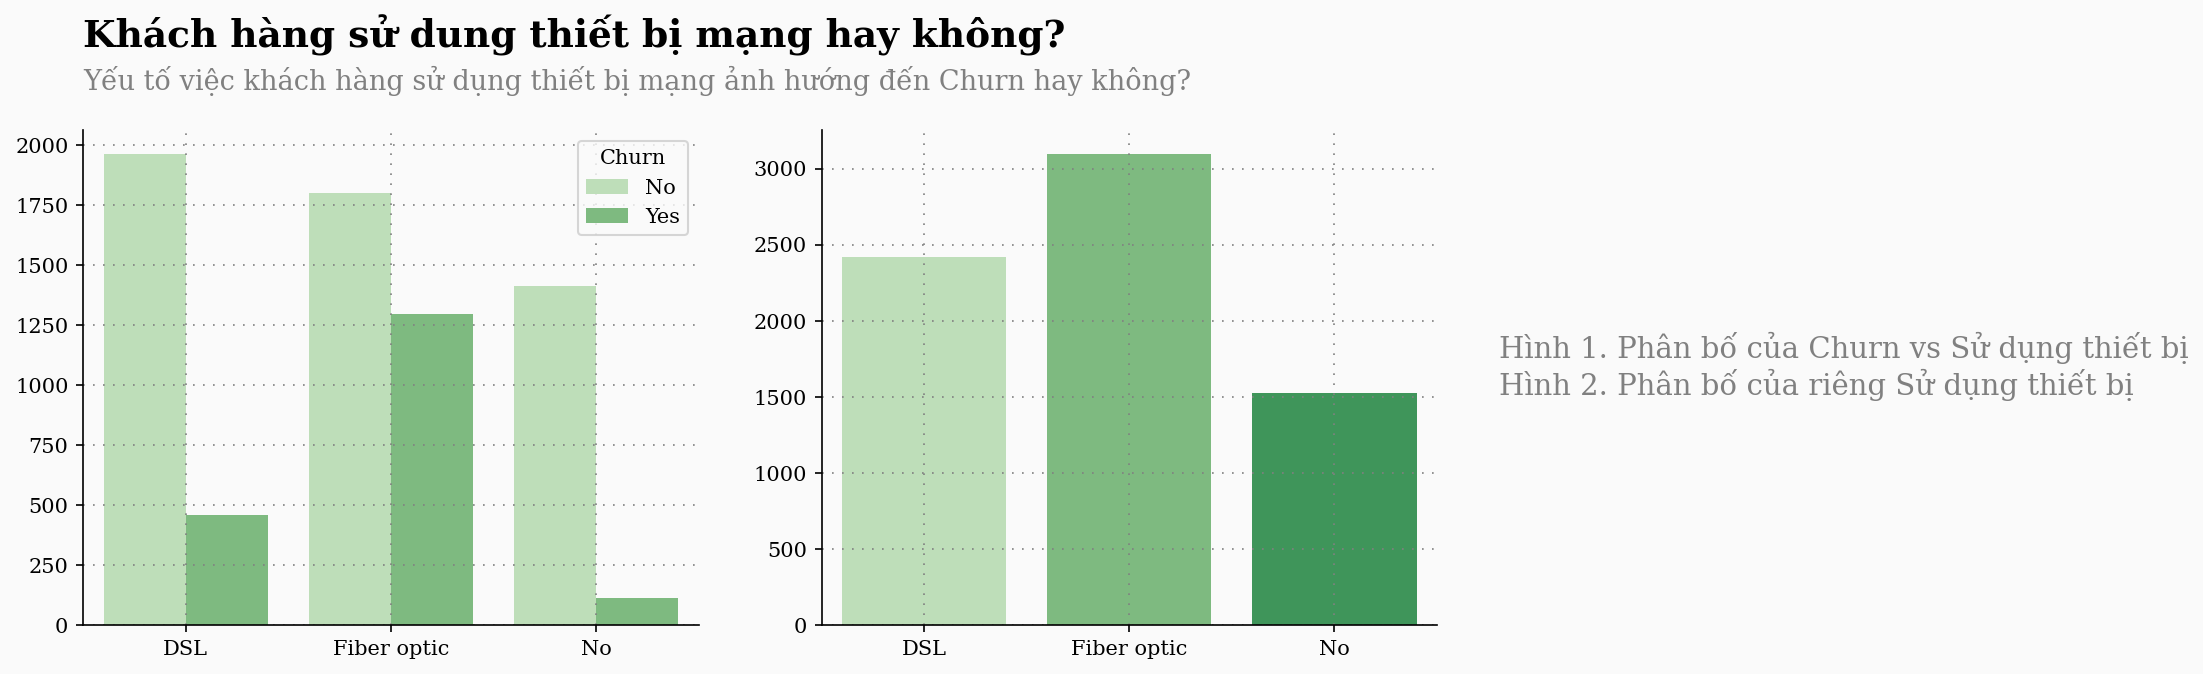

In [274]:
telco_socials = telco[socials]

fig = plt.figure(figsize=(18,15))
gs = fig.add_gridspec(3, 3)
gs.update(wspace=0.2, hspace=0.25)
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[0, 2])


for s in ["right", "top"]:
    ax0.spines[s].set_visible(False)
    ax1.spines[s].set_visible(False)



sns.countplot(ax=ax1, x=telco_socials['InternetService'], palette=palette)
sns.countplot(ax=ax0, x=telco_socials['InternetService'], hue=telco['Churn'], palette=palette)



Xstart, Xend = ax0.get_xlim()
Ystart, Yend = ax0.get_ylim()

ax0.set_ylim([0,Yend])
ax0.text(Xstart,Yend+(Yend*0.15), "Khách hàng sử dung thiết bị mạng hay không?", fontsize=18, ha="left", va="bottom", weight="bold")
ax0.text(Xstart,Yend+(Yend*0.13), "Yếu tố việc khách hàng sử dụng thiết bị mạng ảnh hướng đến Churn hay không?", color="gray",
fontsize=13, ha="left", va="top")

ax0.set_xlabel("")
ax0.set_ylabel("")
ax1.set_xlabel("")
ax1.set_ylabel("")

ax0.grid(which='major', axis='x', zorder=0, color='gray', linestyle=':', dashes=(1,5))
ax0.grid(color='gray', linestyle=':', axis='y', zorder=0,  dashes=(1,5))
ax1.grid(which='major', axis='x', zorder=0, color='gray', linestyle=':', dashes=(1,5))
ax1.grid(color='gray', linestyle=':', axis='y', zorder=0,  dashes=(1,5))


ax2.axis('off')  # Ẩn trục
ax2.text(-0.1, 0.4,
             "Hình 1. Phân bố của Churn vs Sử dụng thiết bị\n"
             "Hình 2. Phân bố của riêng Sử dụng thiết bị\n",
             fontsize=14,  color="gray")

plt.show()

**Nhận xét**

Phân bố của cả 3 mẫu trong đặc trưng không đồng đều nhiết nhất chính là mẫu sử dụng cáp quan ta tiếp theo là DSL và nhóm thấp nhất là không

Phân bố của Churn và không Churn cũng tương đòng về mặt so sánh đều không rời bỏ nhiều hơn

Tuy nhiên tỷ lệ không rời bỏ của DSL và không chệnh lệch mạnh với rời bỏ

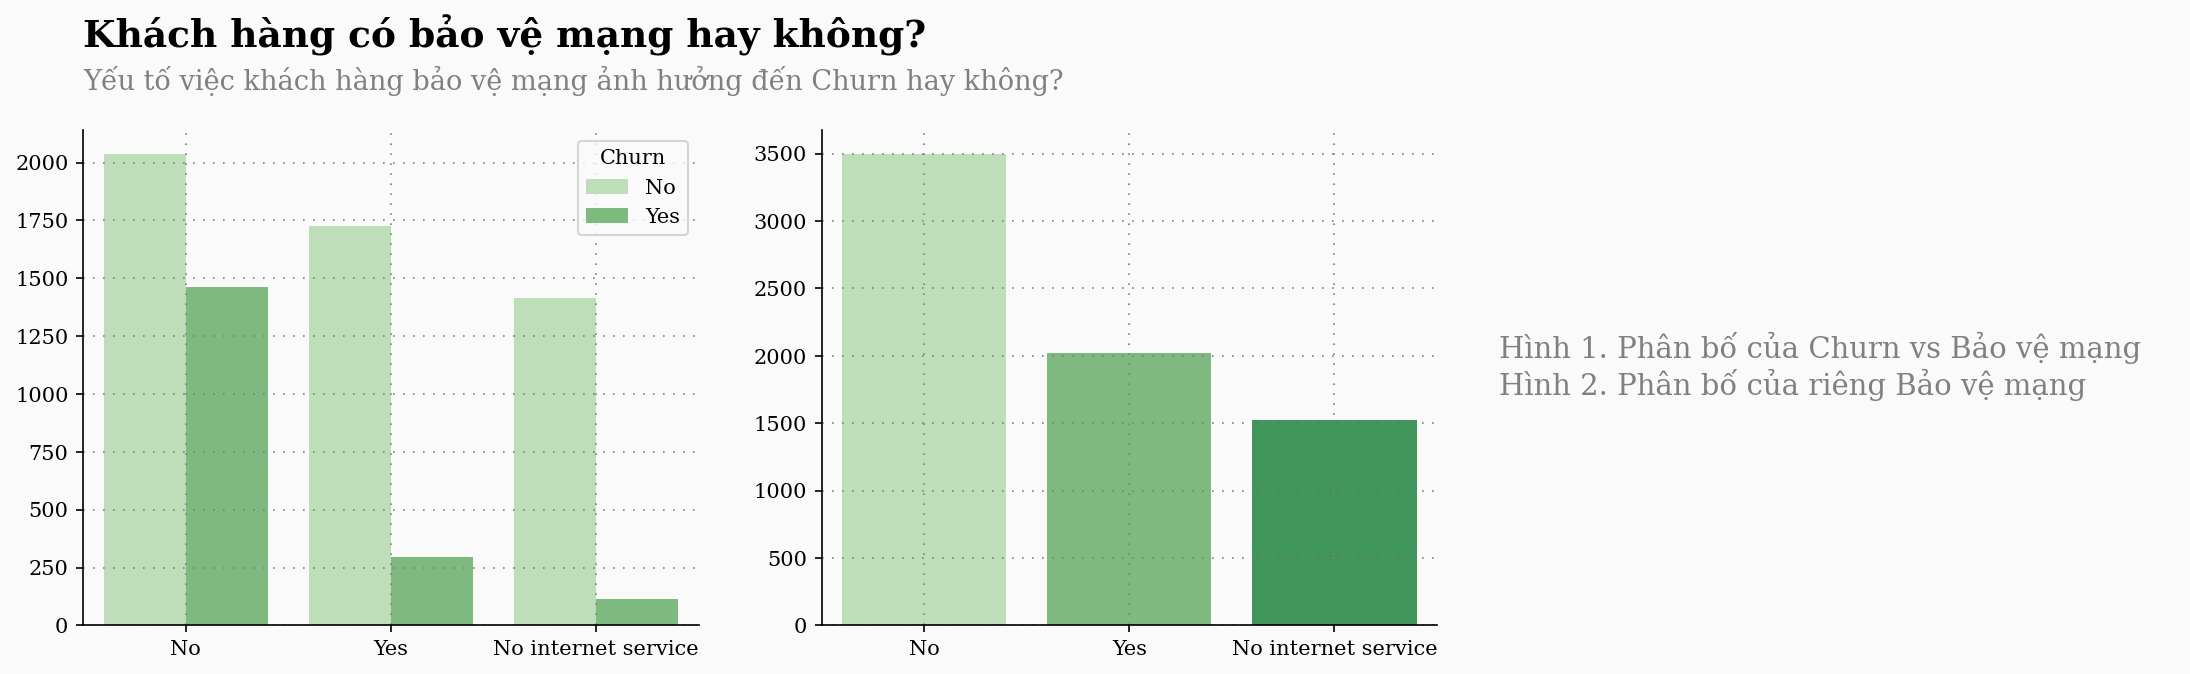

In [275]:
telco_socials = telco[socials]

fig = plt.figure(figsize=(18,15))
gs = fig.add_gridspec(3, 3)
gs.update(wspace=0.2, hspace=0.25)
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[0, 2])


for s in ["right", "top"]:
    ax0.spines[s].set_visible(False)
    ax1.spines[s].set_visible(False)



sns.countplot(ax=ax1, x=telco_socials['OnlineSecurity'], palette=palette)
sns.countplot(ax=ax0, x=telco_socials['OnlineSecurity'], hue=telco['Churn'], palette=palette)



Xstart, Xend = ax0.get_xlim()
Ystart, Yend = ax0.get_ylim()

ax0.set_ylim([0,Yend])
ax0.text(Xstart,Yend+(Yend*0.15), "Khách hàng có bảo vệ mạng hay không?", fontsize=18, ha="left", va="bottom", weight="bold")
ax0.text(Xstart,Yend+(Yend*0.13), "Yếu tố việc khách hàng bảo vệ mạng ảnh hưởng đến Churn hay không?", color="gray",
fontsize=13, ha="left", va="top")

ax0.set_xlabel("")
ax0.set_ylabel("")
ax1.set_xlabel("")
ax1.set_ylabel("")

ax0.grid(which='major', axis='x', zorder=0, color='gray', linestyle=':', dashes=(1,5))
ax0.grid(color='gray', linestyle=':', axis='y', zorder=0,  dashes=(1,5))
ax1.grid(which='major', axis='x', zorder=0, color='gray', linestyle=':', dashes=(1,5))
ax1.grid(color='gray', linestyle=':', axis='y', zorder=0,  dashes=(1,5))


ax2.axis('off')  # Ẩn trục
ax2.text(-0.1, 0.4,
             "Hình 1. Phân bố của Churn vs Bảo vệ mạng\n"
             "Hình 2. Phân bố của riêng Bảo vệ mạng\n",
             fontsize=14,  color="gray")

plt.show()

**Nhận xét**

Không bảo hiểm mạng chiếm nhiều hơn và tỷ lệ không rời bo của thuộc tính này cũng sẽ chiếm nhiều hơn hai thuộc tính còn lại

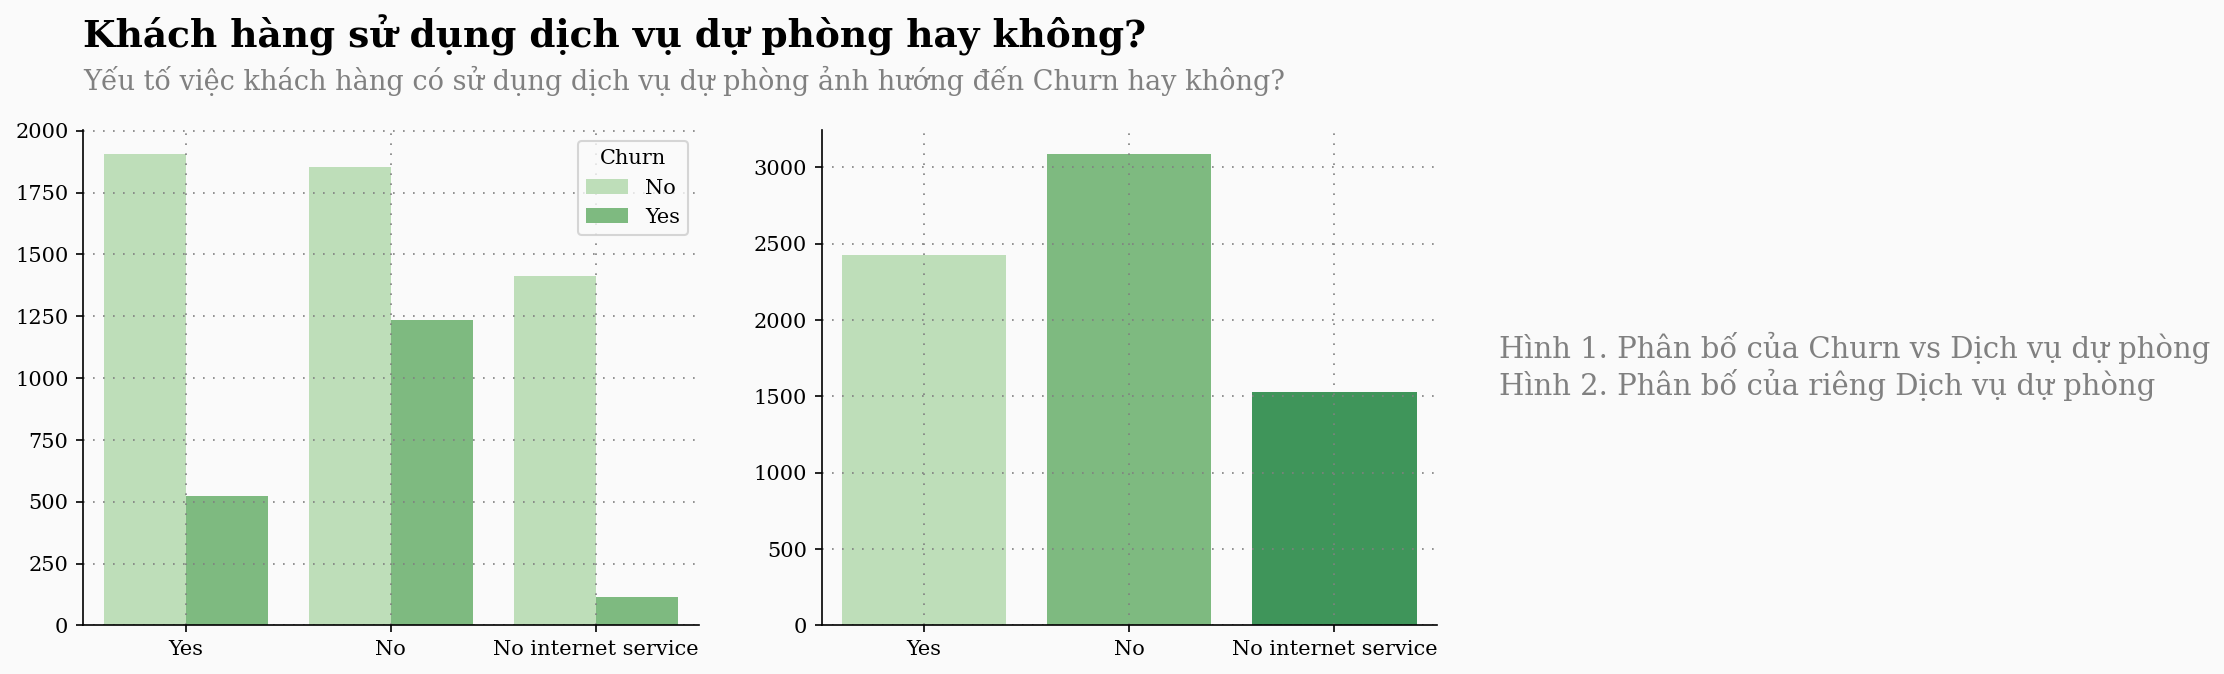

In [276]:
telco_socials = telco[socials]

fig = plt.figure(figsize=(18,15))
gs = fig.add_gridspec(3, 3)
gs.update(wspace=0.2, hspace=0.25)
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[0, 2])


for s in ["right", "top"]:
    ax0.spines[s].set_visible(False)
    ax1.spines[s].set_visible(False)



sns.countplot(ax=ax1, x=telco_socials['OnlineBackup'], palette=palette)
sns.countplot(ax=ax0, x=telco_socials['OnlineBackup'], hue=telco['Churn'], palette=palette)



Xstart, Xend = ax0.get_xlim()
Ystart, Yend = ax0.get_ylim()

ax0.set_ylim([0,Yend])
ax0.text(Xstart,Yend+(Yend*0.15), "Khách hàng sử dụng dịch vụ dự phòng hay không?", fontsize=18, ha="left", va="bottom", weight="bold")
ax0.text(Xstart,Yend+(Yend*0.13), "Yếu tố việc khách hàng có sử dụng dịch vụ dự phòng ảnh hướng đến Churn hay không?", color="gray",
fontsize=13, ha="left", va="top")

ax0.set_xlabel("")
ax0.set_ylabel("")
ax1.set_xlabel("")
ax1.set_ylabel("")

ax0.grid(which='major', axis='x', zorder=0, color='gray', linestyle=':', dashes=(1,5))
ax0.grid(color='gray', linestyle=':', axis='y', zorder=0,  dashes=(1,5))
ax1.grid(which='major', axis='x', zorder=0, color='gray', linestyle=':', dashes=(1,5))
ax1.grid(color='gray', linestyle=':', axis='y', zorder=0,  dashes=(1,5))


ax2.axis('off')  # Ẩn trục
ax2.text(-0.1, 0.4,
             "Hình 1. Phân bố của Churn vs Dịch vụ dự phòng\n"
             "Hình 2. Phân bố của riêng Dịch vụ dự phòng\n",
             fontsize=14,  color="gray")

plt.show()

**Nhận xét**

Yếu tố thuộc trong đặc trưng có phân nố cũng như khá tương đồng với đặc trưng bên trên

Báo trước rằng yếu tố này không ảnh hưởng mạnh đến khả năng rời bỏ

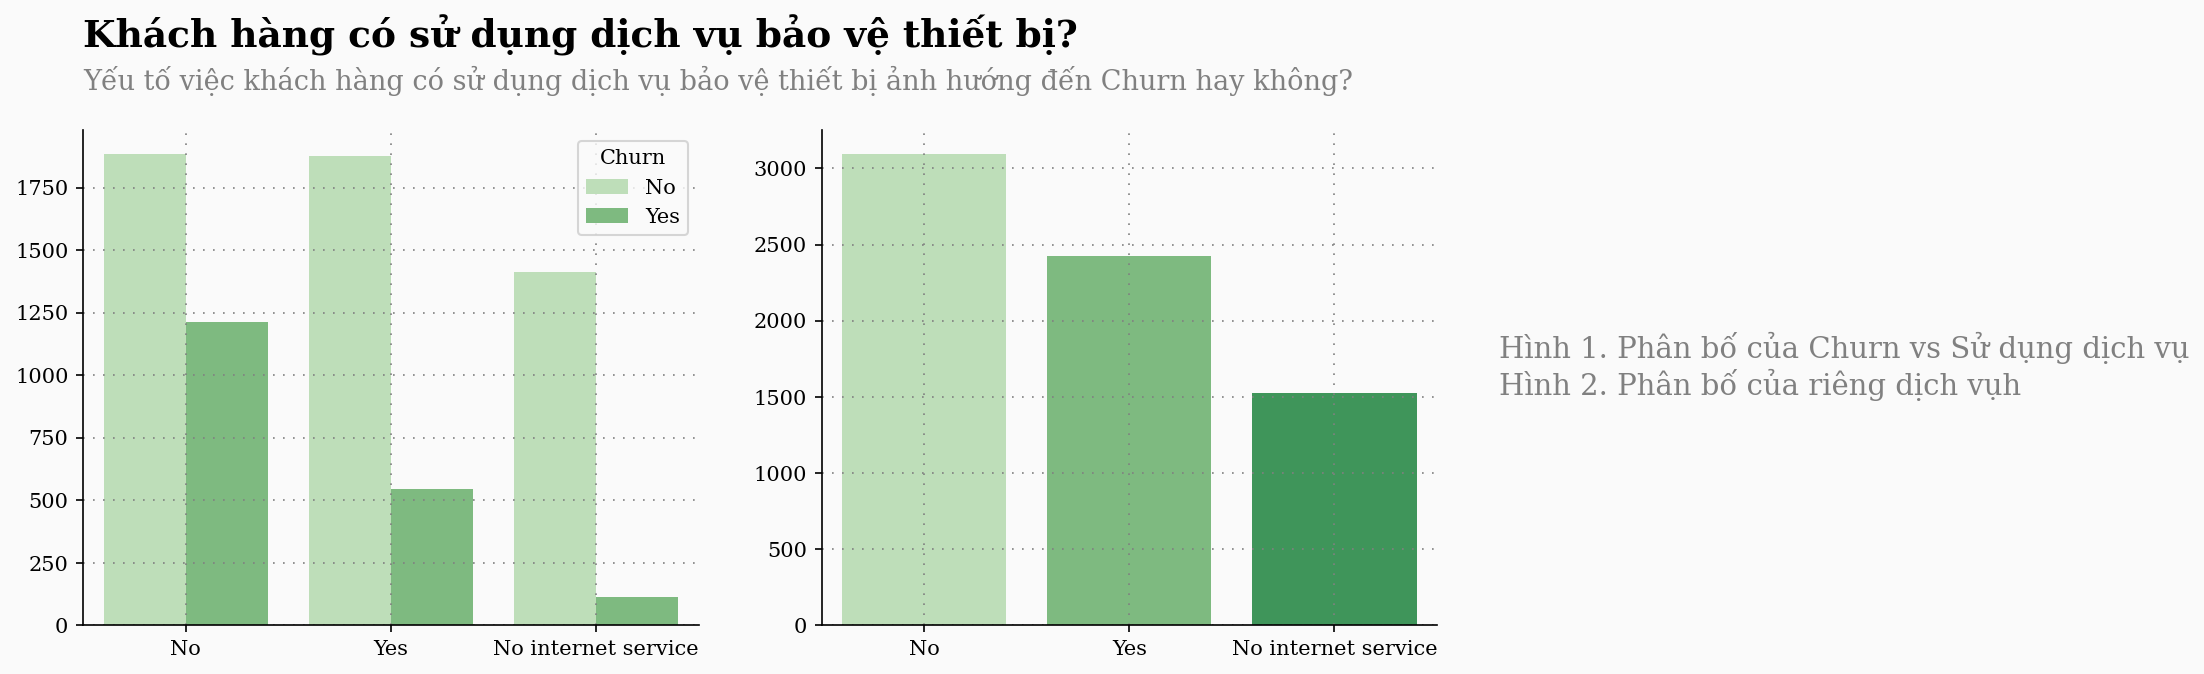

In [277]:
telco_socials = telco[socials]

fig = plt.figure(figsize=(18,15))
gs = fig.add_gridspec(3, 3)
gs.update(wspace=0.2, hspace=0.25)
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[0, 2])


for s in ["right", "top"]:
    ax0.spines[s].set_visible(False)
    ax1.spines[s].set_visible(False)



sns.countplot(ax=ax1, x=telco_socials['DeviceProtection'], palette=palette)
sns.countplot(ax=ax0, x=telco_socials['DeviceProtection'], hue=telco['Churn'], palette=palette)



Xstart, Xend = ax0.get_xlim()
Ystart, Yend = ax0.get_ylim()

ax0.set_ylim([0,Yend])
ax0.text(Xstart,Yend+(Yend*0.15), "Khách hàng có sử dụng dịch vụ bảo vệ thiết bị?", fontsize=18, ha="left", va="bottom", weight="bold")
ax0.text(Xstart,Yend+(Yend*0.13), "Yếu tố việc khách hàng có sử dụng dịch vụ bảo vệ thiết bị ảnh hướng đến Churn hay không?", color="gray",
fontsize=13, ha="left", va="top")

ax0.set_xlabel("")
ax0.set_ylabel("")
ax1.set_xlabel("")
ax1.set_ylabel("")

ax0.grid(which='major', axis='x', zorder=0, color='gray', linestyle=':', dashes=(1,5))
ax0.grid(color='gray', linestyle=':', axis='y', zorder=0,  dashes=(1,5))
ax1.grid(which='major', axis='x', zorder=0, color='gray', linestyle=':', dashes=(1,5))
ax1.grid(color='gray', linestyle=':', axis='y', zorder=0,  dashes=(1,5))


ax2.axis('off')  # Ẩn trục
ax2.text(-0.1, 0.4,
             "Hình 1. Phân bố của Churn vs Sử dụng dịch vụ\n"
             "Hình 2. Phân bố của riêng dịch vụh\n",
             fontsize=14,  color="gray")

plt.show()

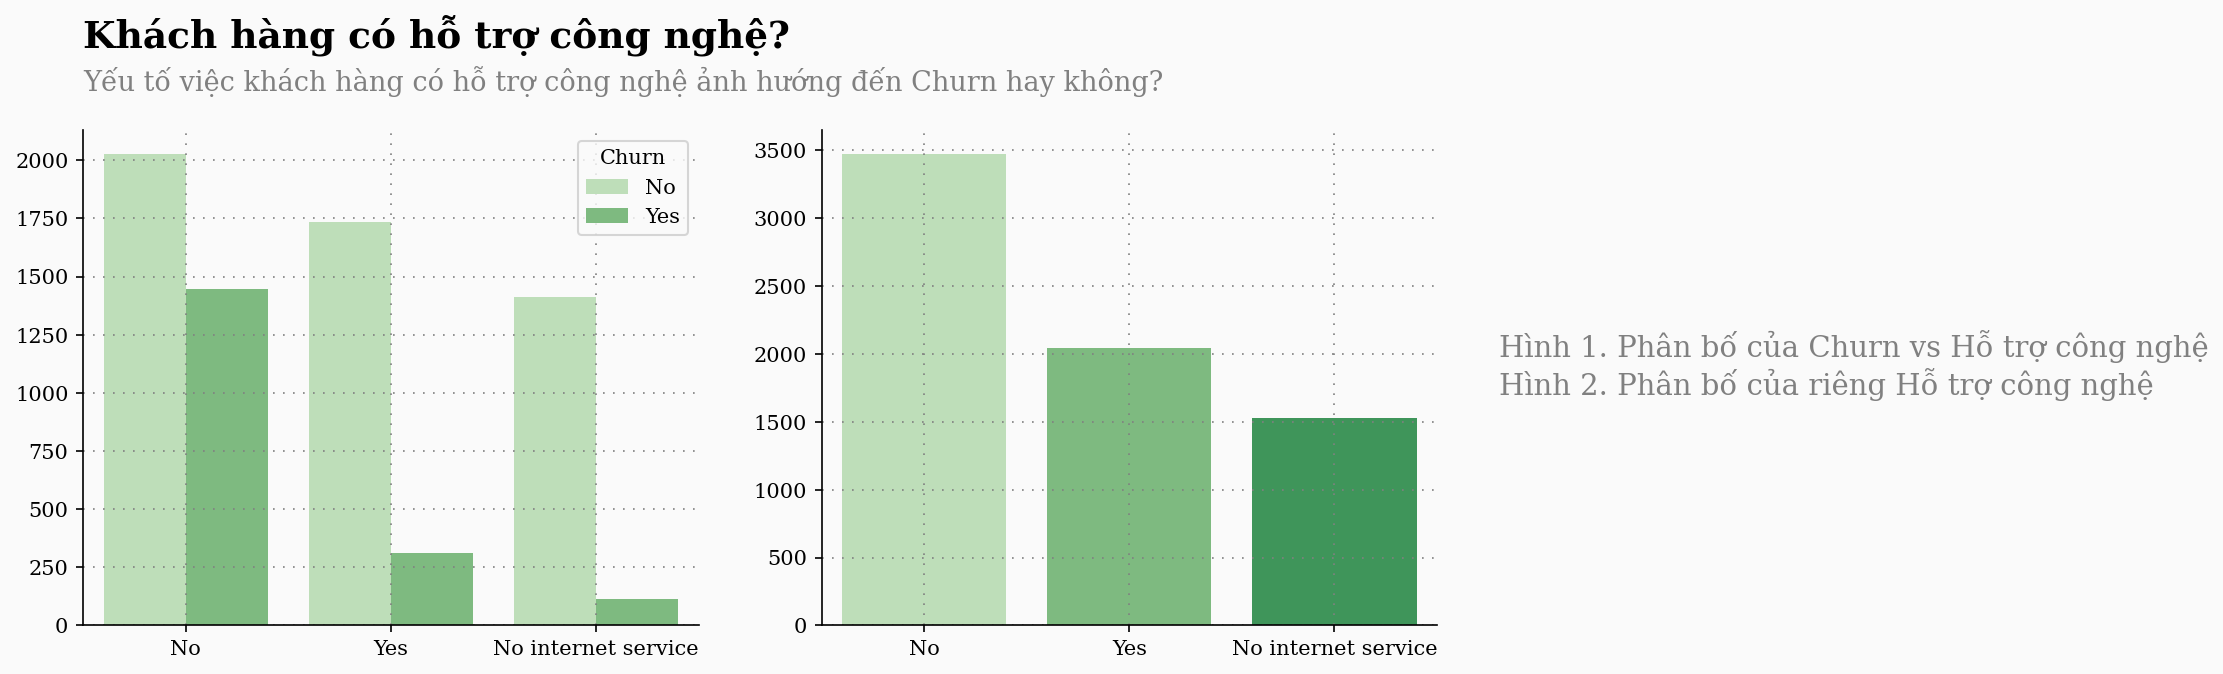

In [278]:
telco_socials = telco[socials]

fig = plt.figure(figsize=(18,15))
gs = fig.add_gridspec(3, 3)
gs.update(wspace=0.2, hspace=0.25)
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[0, 2])


for s in ["right", "top"]:
    ax0.spines[s].set_visible(False)
    ax1.spines[s].set_visible(False)



sns.countplot(ax=ax1, x=telco_socials['TechSupport'], palette=palette)
sns.countplot(ax=ax0, x=telco_socials['TechSupport'], hue=telco['Churn'], palette=palette)



Xstart, Xend = ax0.get_xlim()
Ystart, Yend = ax0.get_ylim()

ax0.set_ylim([0,Yend])
ax0.text(Xstart,Yend+(Yend*0.15), "Khách hàng có hỗ trợ công nghệ?", fontsize=18, ha="left", va="bottom", weight="bold")
ax0.text(Xstart,Yend+(Yend*0.13), "Yếu tố việc khách hàng có hỗ trợ công nghệ ảnh hướng đến Churn hay không?", color="gray",
fontsize=13, ha="left", va="top")

ax0.set_xlabel("")
ax0.set_ylabel("")
ax1.set_xlabel("")
ax1.set_ylabel("")

ax0.grid(which='major', axis='x', zorder=0, color='gray', linestyle=':', dashes=(1,5))
ax0.grid(color='gray', linestyle=':', axis='y', zorder=0,  dashes=(1,5))
ax1.grid(which='major', axis='x', zorder=0, color='gray', linestyle=':', dashes=(1,5))
ax1.grid(color='gray', linestyle=':', axis='y', zorder=0,  dashes=(1,5))


ax2.axis('off')  # Ẩn trục
ax2.text(-0.1, 0.4,
             "Hình 1. Phân bố của Churn vs Hỗ trợ công nghệ\n"
             "Hình 2. Phân bố của riêng Hỗ trợ công nghệ\n",
             fontsize=14,  color="gray")

plt.show()

## **🤝 Relationships Factors vs Churn (So sánh Churn và Không Churn theo các thống tin liên lạc)**



In [279]:
relations = ['PhoneService', 'MultipleLines']

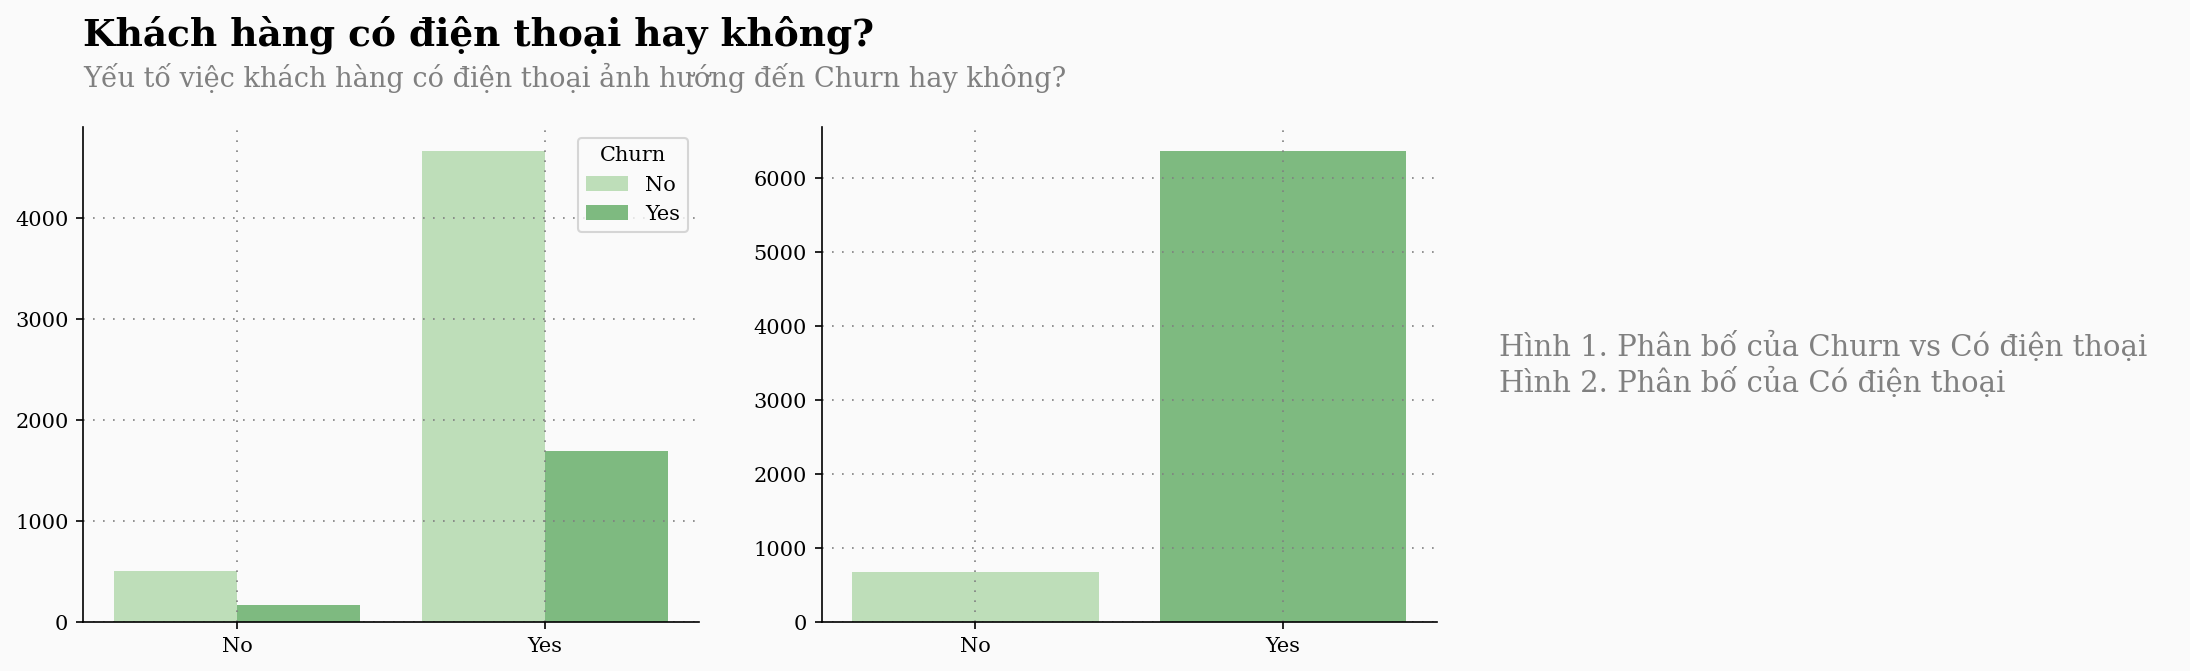

In [280]:
telco_relations = telco[relations]

fig = plt.figure(figsize=(18,15))
gs = fig.add_gridspec(3, 3)
gs.update(wspace=0.2, hspace=0.25)
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[0, 2])


for s in ["right", "top"]:
    ax0.spines[s].set_visible(False)
    ax1.spines[s].set_visible(False)



sns.countplot(ax=ax1, x=telco_relations['PhoneService'], palette=palette)
sns.countplot(ax=ax0, x=telco_relations['PhoneService'], hue=telco['Churn'], palette=palette)



Xstart, Xend = ax0.get_xlim()
Ystart, Yend = ax0.get_ylim()

ax0.set_ylim([0,Yend])
ax0.text(Xstart,Yend+(Yend*0.15), "Khách hàng có điện thoại hay không?", fontsize=18, ha="left", va="bottom", weight="bold")
ax0.text(Xstart,Yend+(Yend*0.13), "Yếu tố việc khách hàng có điện thoại ảnh hướng đến Churn hay không?", color="gray",
fontsize=13, ha="left", va="top")

ax0.set_xlabel("")
ax0.set_ylabel("")
ax1.set_xlabel("")
ax1.set_ylabel("")

ax0.grid(which='major', axis='x', zorder=0, color='gray', linestyle=':', dashes=(1,5))
ax0.grid(color='gray', linestyle=':', axis='y', zorder=0,  dashes=(1,5))
ax1.grid(which='major', axis='x', zorder=0, color='gray', linestyle=':', dashes=(1,5))
ax1.grid(color='gray', linestyle=':', axis='y', zorder=0,  dashes=(1,5))


ax2.axis('off')  # Ẩn trục
ax2.text(-0.1, 0.4,
             "Hình 1. Phân bố của Churn vs Có điện thoại\n"
             "Hình 2. Phân bố của Có điện thoại\n",
             fontsize=14,  color="gray")

plt.show()

**Nhận xét**

Điều này là hiển nhiên do dữ liệu được lấy từ mẫu thương mại Telecom nên số mẫu có sử dụng điện thoại nhiều hơn không

Tuy nhiên một điều bất ngờ rằng dù bất kể khách hàng có sử dụng điện thoại hay không thì họ cũng sẽ rời bỏ, và tỷ lệ rời bỏ của cả hai thuộc tính của đặc trưng này chiếm nhièu ở không rời bỏ

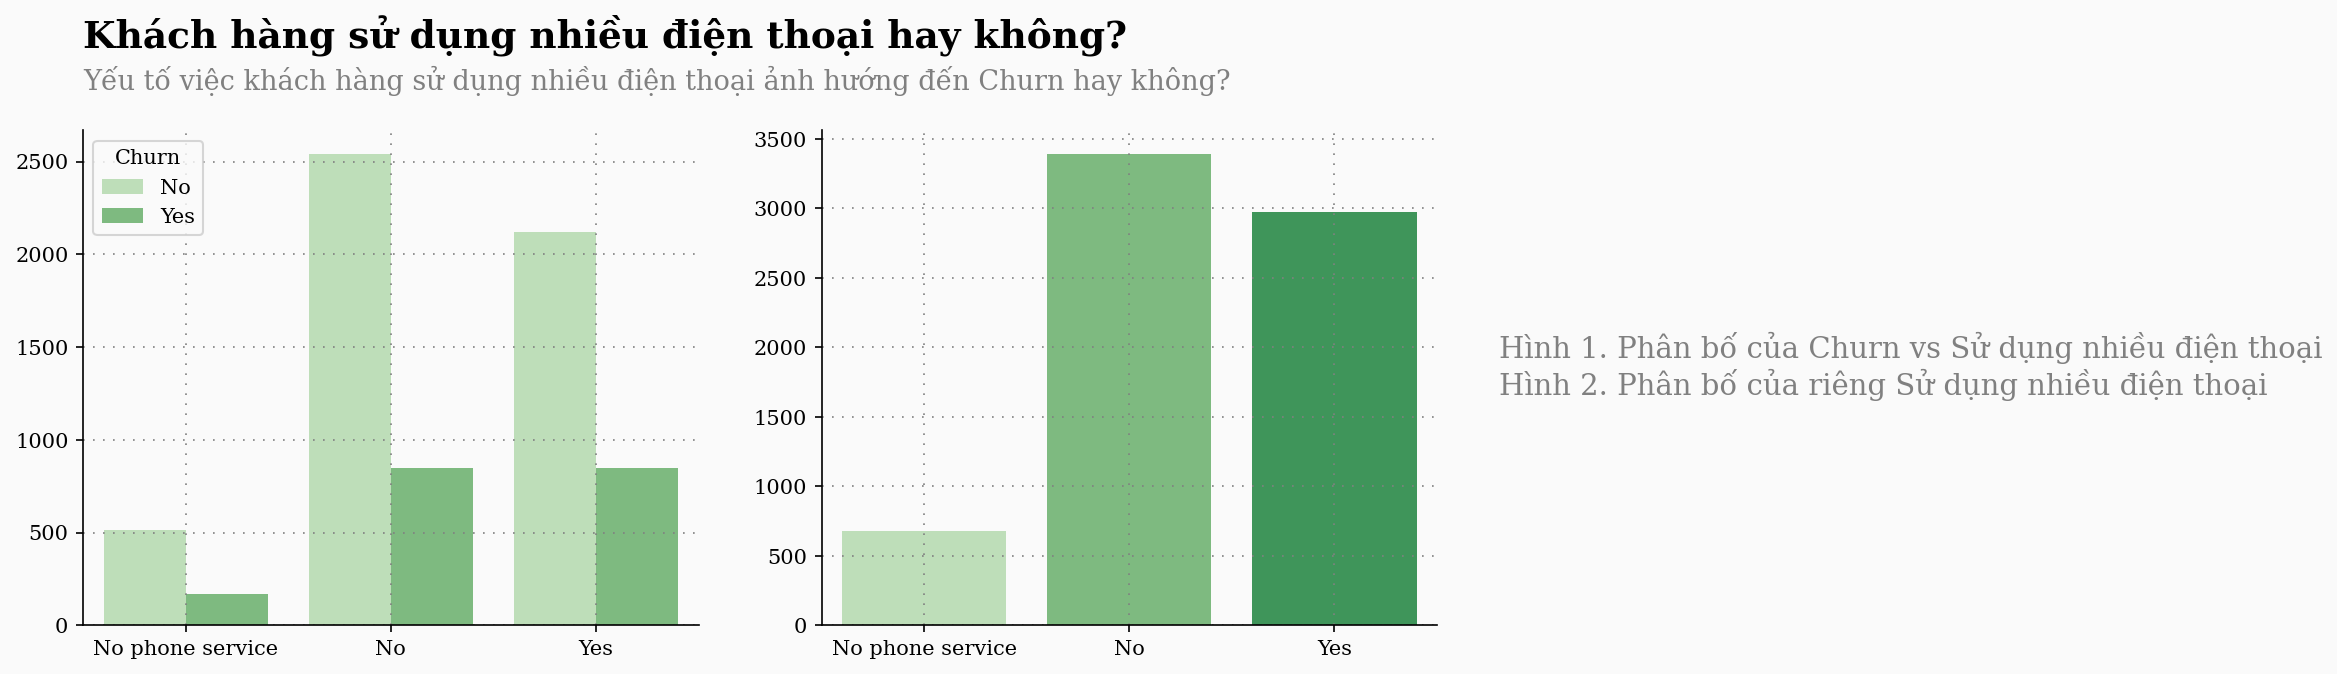

In [281]:
telco_relations = telco[relations]

fig = plt.figure(figsize=(18,15))
gs = fig.add_gridspec(3, 3)
gs.update(wspace=0.2, hspace=0.25)
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[0, 2])


for s in ["right", "top"]:
    ax0.spines[s].set_visible(False)
    ax1.spines[s].set_visible(False)



sns.countplot(ax=ax1, x=telco_relations['MultipleLines'], palette=palette)
sns.countplot(ax=ax0, x=telco_relations['MultipleLines'], hue=telco['Churn'], palette=palette)



Xstart, Xend = ax0.get_xlim()
Ystart, Yend = ax0.get_ylim()

ax0.set_ylim([0,Yend])
ax0.text(Xstart,Yend+(Yend*0.15), "Khách hàng sử dụng nhiều điện thoại hay không?", fontsize=18, ha="left", va="bottom", weight="bold")
ax0.text(Xstart,Yend+(Yend*0.13), "Yếu tố việc khách hàng sử dụng nhiều điện thoại ảnh hướng đến Churn hay không?", color="gray",
fontsize=13, ha="left", va="top")

ax0.set_xlabel("")
ax0.set_ylabel("")
ax1.set_xlabel("")
ax1.set_ylabel("")

ax0.grid(which='major', axis='x', zorder=0, color='gray', linestyle=':', dashes=(1,5))
ax0.grid(color='gray', linestyle=':', axis='y', zorder=0,  dashes=(1,5))
ax1.grid(which='major', axis='x', zorder=0, color='gray', linestyle=':', dashes=(1,5))
ax1.grid(color='gray', linestyle=':', axis='y', zorder=0,  dashes=(1,5))


ax2.axis('off')  # Ẩn trục
ax2.text(-0.1, 0.4,
             "Hình 1. Phân bố của Churn vs Sử dụng nhiều điện thoại\n"
             "Hình 2. Phân bố của riêng Sử dụng nhiều điện thoại\n",
             fontsize=14,  color="gray")

plt.show()

**Nhận xét**

Khách hàng không sử dụng nhiều điện bị chiếm nhiều hơn khách hàng không sử dụng thiết bị và sử dụng nhiều thiết bị

Tỷ lệ rời bỏ của cả ba người này đều chiếm nhiều nhất và nhiều khả năng rời bỏ nhất vẫn là nhóm có nhiều điện thoại và không có nhiều điện thoại

## **🔄 Contract Factors vs Churn (So sánh Churn và Không Churn theo các thống tin hợp đồng)**




In [282]:
contracts = ['StreamingTV', 'StreamingMovies', 'Contract',
            'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']

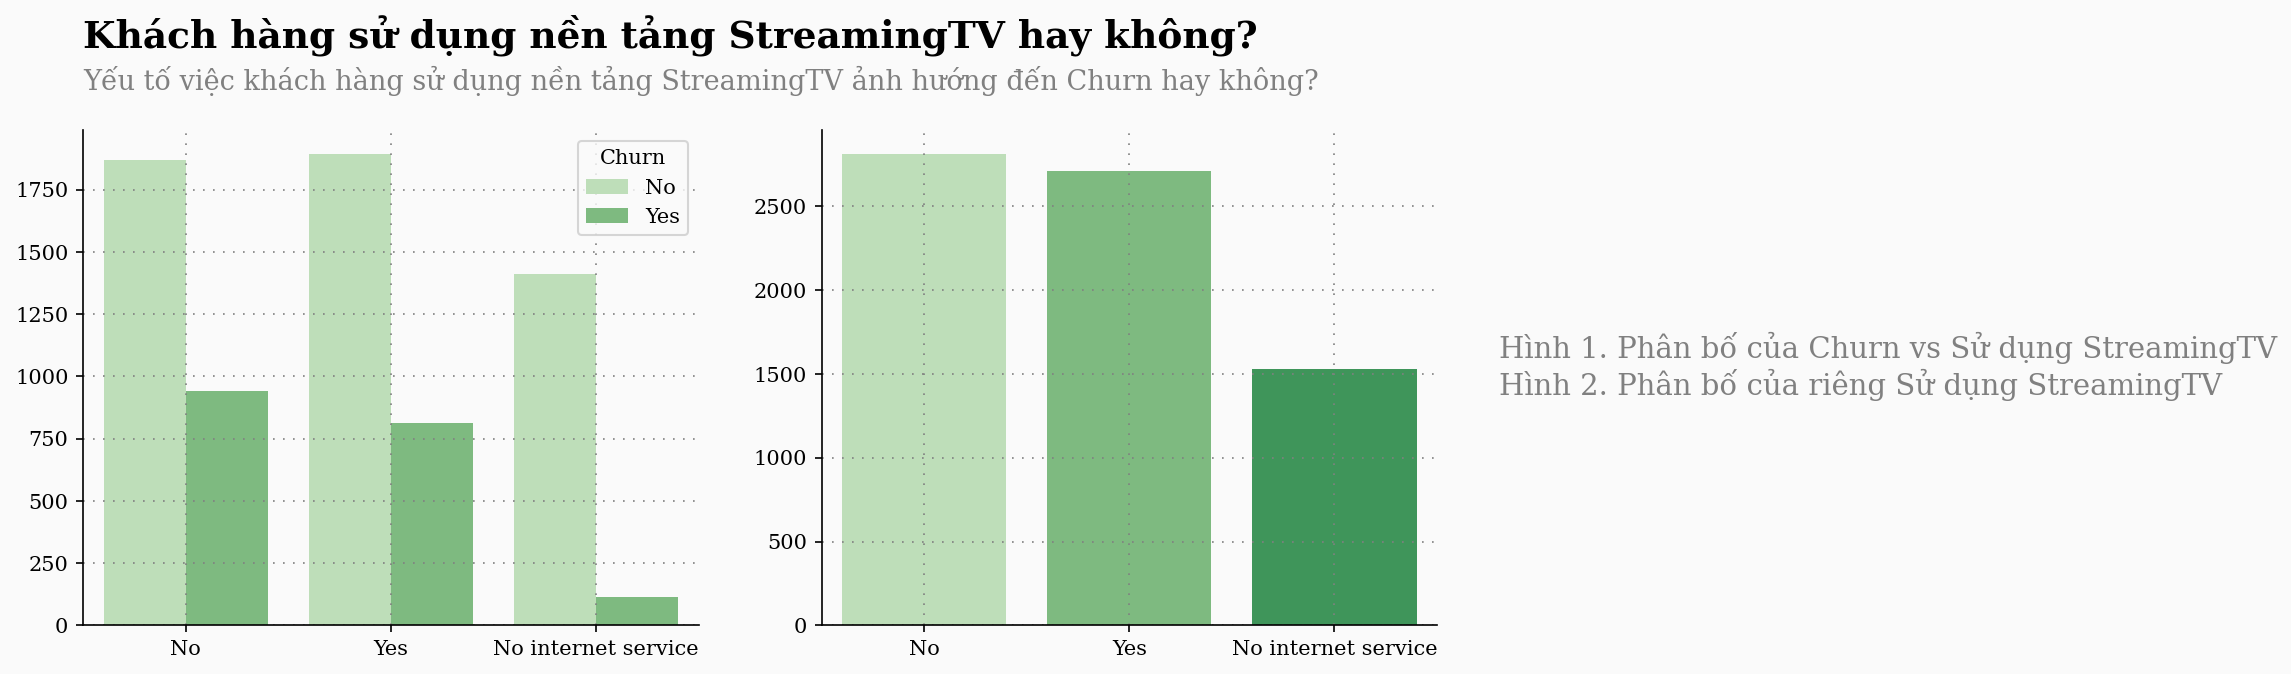

In [283]:
telco_contracts = telco[contracts]

fig = plt.figure(figsize=(18,15))
gs = fig.add_gridspec(3, 3)
gs.update(wspace=0.2, hspace=0.25)
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[0, 2])


for s in ["right", "top"]:
    ax0.spines[s].set_visible(False)
    ax1.spines[s].set_visible(False)



sns.countplot(ax=ax1, x=telco_contracts['StreamingTV'], palette=palette)
sns.countplot(ax=ax0, x=telco_contracts['StreamingTV'], hue=telco['Churn'], palette=palette)



Xstart, Xend = ax0.get_xlim()
Ystart, Yend = ax0.get_ylim()

ax0.set_ylim([0,Yend])
ax0.text(Xstart,Yend+(Yend*0.15), "Khách hàng sử dụng nền tảng StreamingTV hay không?", fontsize=18, ha="left", va="bottom", weight="bold")
ax0.text(Xstart,Yend+(Yend*0.13), "Yếu tố việc khách hàng sử dụng nền tảng StreamingTV ảnh hướng đến Churn hay không?", color="gray",
fontsize=13, ha="left", va="top")

ax0.set_xlabel("")
ax0.set_ylabel("")
ax1.set_xlabel("")
ax1.set_ylabel("")

ax0.grid(which='major', axis='x', zorder=0, color='gray', linestyle=':', dashes=(1,5))
ax0.grid(color='gray', linestyle=':', axis='y', zorder=0,  dashes=(1,5))
ax1.grid(which='major', axis='x', zorder=0, color='gray', linestyle=':', dashes=(1,5))
ax1.grid(color='gray', linestyle=':', axis='y', zorder=0,  dashes=(1,5))


ax2.axis('off')  # Ẩn trục
ax2.text(-0.1, 0.4,
             "Hình 1. Phân bố của Churn vs Sử dụng StreamingTV\n"
             "Hình 2. Phân bố của riêng Sử dụng StreamingTV\n",
             fontsize=14,  color="gray")

plt.show()

**Nhận xét**

Bất ngờ trong bảng dữ liệu số người sử dụng dịch vụ và không sử dụng dịch vụ bằng nhau tương đối vẫn có một chút ít hơn so với người sử dụng tuy nhiên ở mức độ rời bỏ thì người không sử dụng dịch vụ rời bỏ nhiều hơn hẳn, mức độ trung thành của người sử dụng dịch vụ cùng nhiều hơn đáng kể

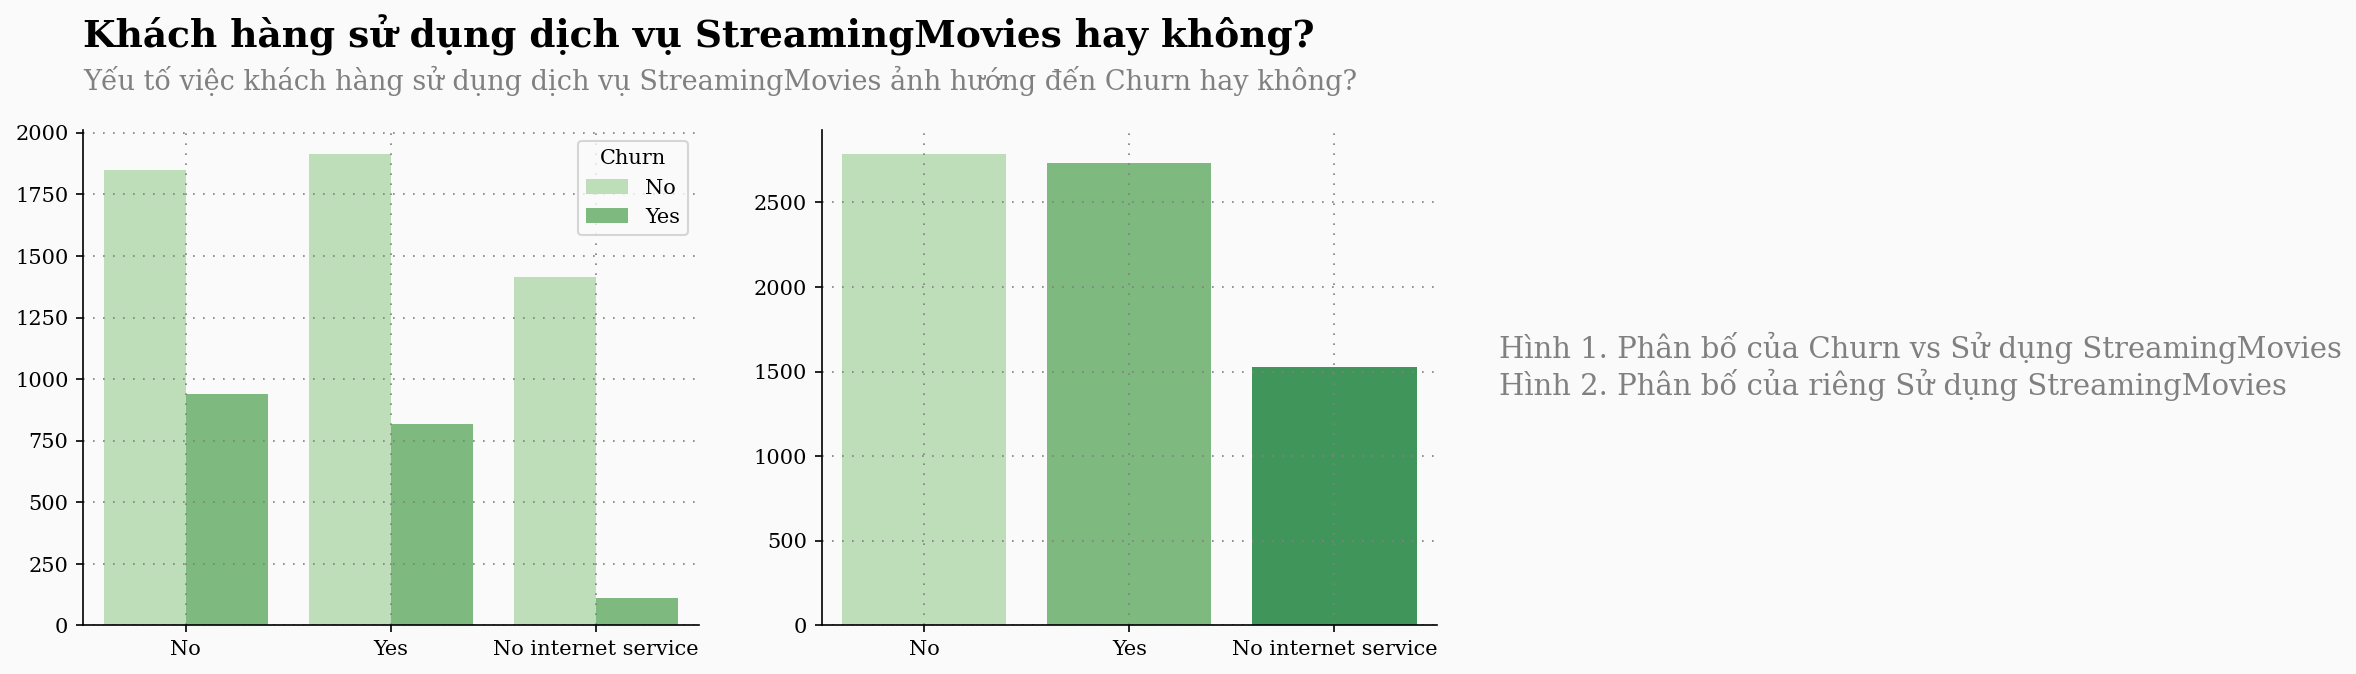

In [284]:
telco_contracts = telco[contracts]

fig = plt.figure(figsize=(18,15))
gs = fig.add_gridspec(3, 3)
gs.update(wspace=0.2, hspace=0.25)
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[0, 2])


for s in ["right", "top"]:
    ax0.spines[s].set_visible(False)
    ax1.spines[s].set_visible(False)



sns.countplot(ax=ax1, x=telco_contracts['StreamingMovies'], palette=palette)
sns.countplot(ax=ax0, x=telco_contracts['StreamingMovies'], hue=telco['Churn'], palette=palette)



Xstart, Xend = ax0.get_xlim()
Ystart, Yend = ax0.get_ylim()

ax0.set_ylim([0,Yend])
ax0.text(Xstart,Yend+(Yend*0.15), "Khách hàng sử dụng dịch vụ StreamingMovies hay không?", fontsize=18, ha="left", va="bottom", weight="bold")
ax0.text(Xstart,Yend+(Yend*0.13), "Yếu tố việc khách hàng sử dụng dịch vụ StreamingMovies ảnh hướng đến Churn hay không?", color="gray",
fontsize=13, ha="left", va="top")

ax0.set_xlabel("")
ax0.set_ylabel("")
ax1.set_xlabel("")
ax1.set_ylabel("")

ax0.grid(which='major', axis='x', zorder=0, color='gray', linestyle=':', dashes=(1,5))
ax0.grid(color='gray', linestyle=':', axis='y', zorder=0,  dashes=(1,5))
ax1.grid(which='major', axis='x', zorder=0, color='gray', linestyle=':', dashes=(1,5))
ax1.grid(color='gray', linestyle=':', axis='y', zorder=0,  dashes=(1,5))


ax2.axis('off')  # Ẩn trục
ax2.text(-0.1, 0.4,
             "Hình 1. Phân bố của Churn vs Sử dụng StreamingMovies\n"
             "Hình 2. Phân bố của riêng Sử dụng StreamingMovies\n",
             fontsize=14,  color="gray")

plt.show()

**Nhận xét**

Tương tự như StreamingTV ta cũng có quan sát tương tụ ở đặc trưng StreamingMovies

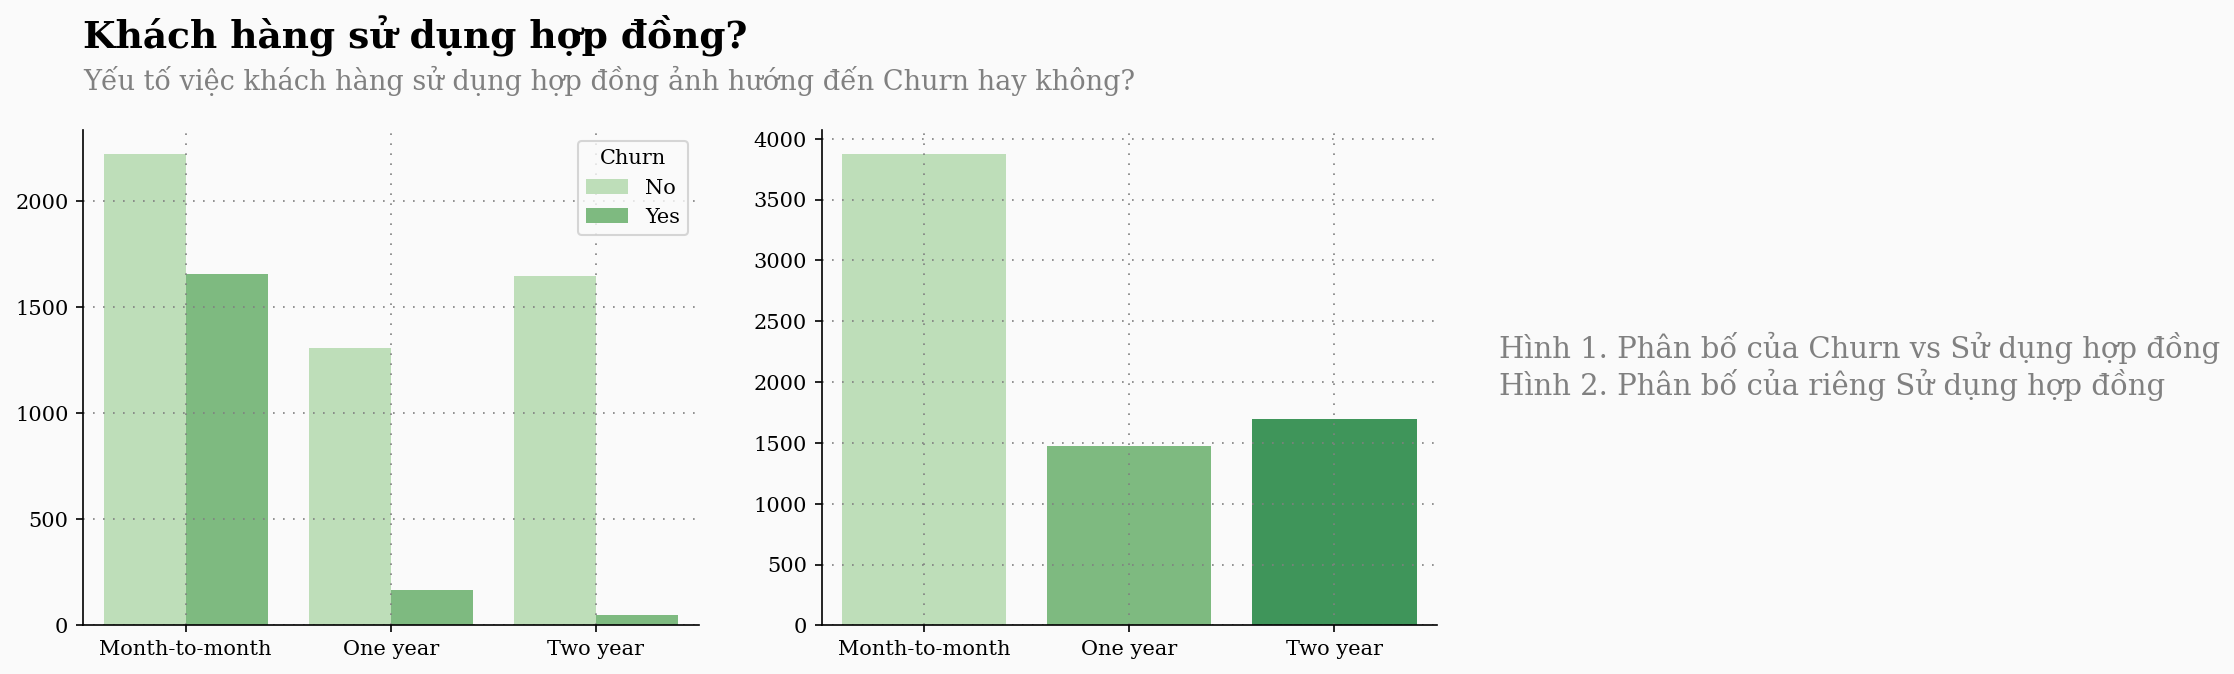

In [285]:
telco_contracts = telco[contracts]

fig = plt.figure(figsize=(18,15))
gs = fig.add_gridspec(3, 3)
gs.update(wspace=0.2, hspace=0.25)
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[0, 2])


for s in ["right", "top"]:
    ax0.spines[s].set_visible(False)
    ax1.spines[s].set_visible(False)



sns.countplot(ax=ax1, x=telco_contracts['Contract'], palette=palette)
sns.countplot(ax=ax0, x=telco_contracts['Contract'], hue=telco['Churn'], palette=palette)



Xstart, Xend = ax0.get_xlim()
Ystart, Yend = ax0.get_ylim()

ax0.set_ylim([0,Yend])
ax0.text(Xstart,Yend+(Yend*0.15), "Khách hàng sử dụng hợp đồng?", fontsize=18, ha="left", va="bottom", weight="bold")
ax0.text(Xstart,Yend+(Yend*0.13), "Yếu tố việc khách hàng sử dụng hợp đồng ảnh hướng đến Churn hay không?", color="gray",
fontsize=13, ha="left", va="top")

ax0.set_xlabel("")
ax0.set_ylabel("")
ax1.set_xlabel("")
ax1.set_ylabel("")

ax0.grid(which='major', axis='x', zorder=0, color='gray', linestyle=':', dashes=(1,5))
ax0.grid(color='gray', linestyle=':', axis='y', zorder=0,  dashes=(1,5))
ax1.grid(which='major', axis='x', zorder=0, color='gray', linestyle=':', dashes=(1,5))
ax1.grid(color='gray', linestyle=':', axis='y', zorder=0,  dashes=(1,5))


ax2.axis('off')  # Ẩn trục
ax2.text(-0.1, 0.4,
             "Hình 1. Phân bố của Churn vs Sử dụng hợp đồng\n"
             "Hình 2. Phân bố của riêng Sử dụng hợp đồng\n",
             fontsize=14,  color="gray")

plt.show()

**Nhận xét**

Đa số khách hàng trong bảng dữ liệu sử dụng hợp đồng trả theo tháng nhiều hơn đáng kẻ so với 2 loại hợp đồng còn lại, khả năng rời bỏ của hợp đồng này cũng nhiều nhất và trung thàn cũng nhiều nhất. Tuy nhiên ngạc nhiên nhóm 2 năm lại nhiều hơn nhóm 1 năm và có khả năng rời bỏ cực kỳ ít

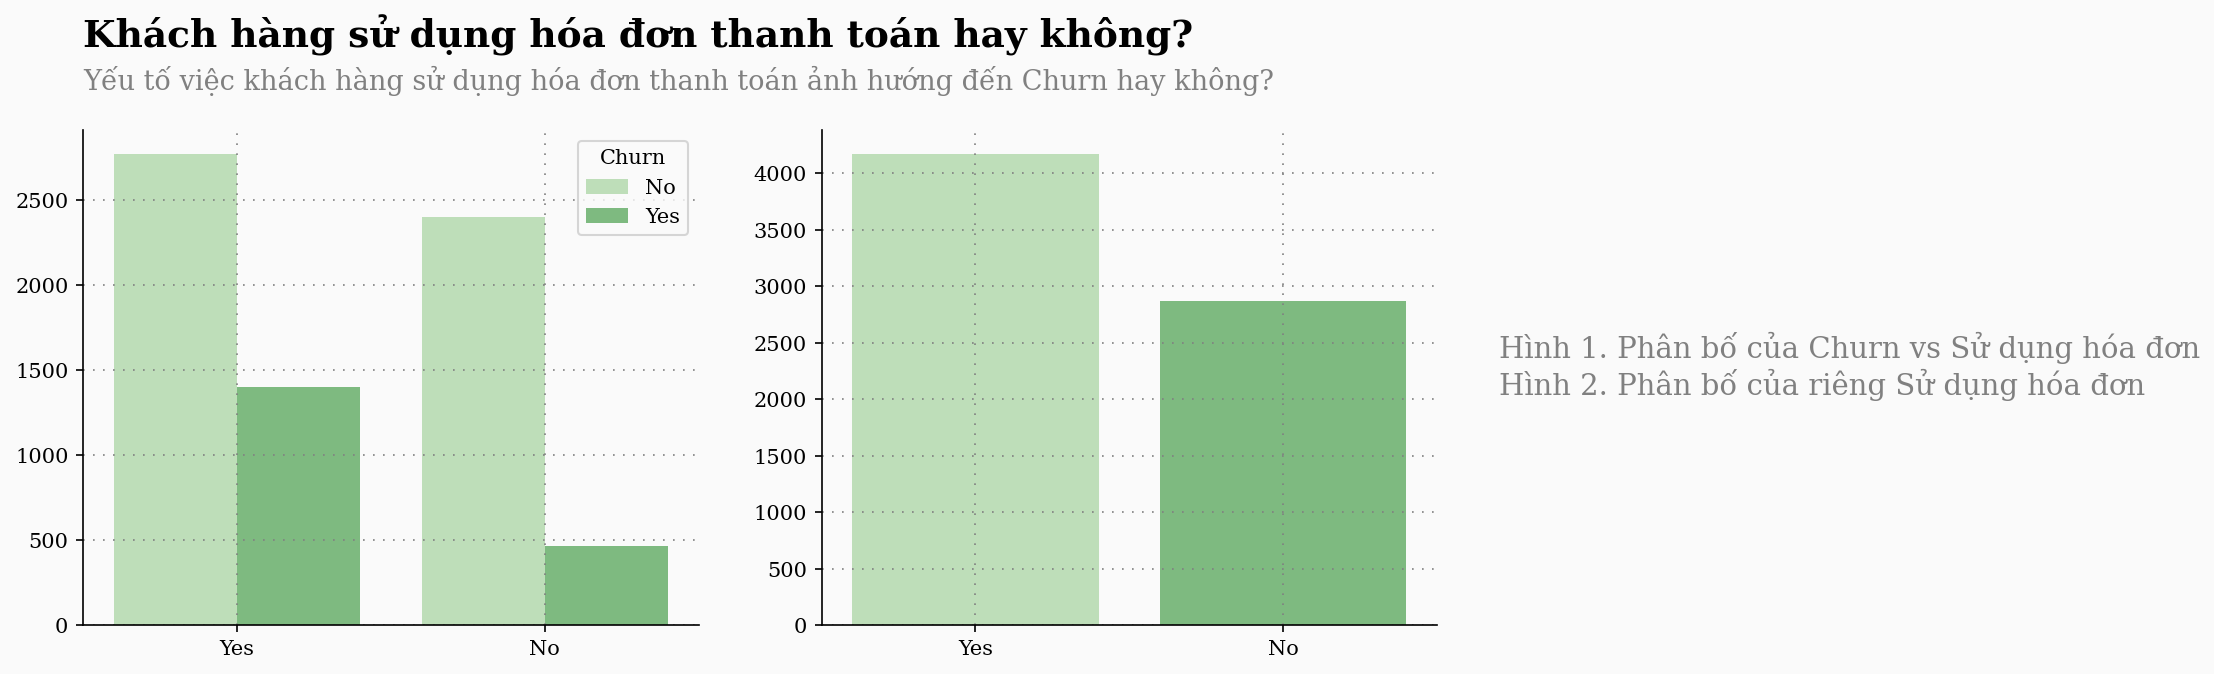

In [286]:
telco_contracts = telco[contracts]

fig = plt.figure(figsize=(18,15))
gs = fig.add_gridspec(3, 3)
gs.update(wspace=0.2, hspace=0.25)
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[0, 2])


for s in ["right", "top"]:
    ax0.spines[s].set_visible(False)
    ax1.spines[s].set_visible(False)



sns.countplot(ax=ax1, x=telco_contracts['PaperlessBilling'], palette=palette)
sns.countplot(ax=ax0, x=telco_contracts['PaperlessBilling'], hue=telco['Churn'], palette=palette)



Xstart, Xend = ax0.get_xlim()
Ystart, Yend = ax0.get_ylim()

ax0.set_ylim([0,Yend])
ax0.text(Xstart,Yend+(Yend*0.15), "Khách hàng sử dụng hóa đơn thanh toán hay không?", fontsize=18, ha="left", va="bottom", weight="bold")
ax0.text(Xstart,Yend+(Yend*0.13), "Yếu tố việc khách hàng sử dụng hóa đơn thanh toán ảnh hướng đến Churn hay không?", color="gray",
fontsize=13, ha="left", va="top")

ax0.set_xlabel("")
ax0.set_ylabel("")
ax1.set_xlabel("")
ax1.set_ylabel("")

ax0.grid(which='major', axis='x', zorder=0, color='gray', linestyle=':', dashes=(1,5))
ax0.grid(color='gray', linestyle=':', axis='y', zorder=0,  dashes=(1,5))
ax1.grid(which='major', axis='x', zorder=0, color='gray', linestyle=':', dashes=(1,5))
ax1.grid(color='gray', linestyle=':', axis='y', zorder=0,  dashes=(1,5))


ax2.axis('off')  # Ẩn trục
ax2.text(-0.1, 0.4,
             "Hình 1. Phân bố của Churn vs Sử dụng hóa đơn\n"
             "Hình 2. Phân bố của riêng Sử dụng hóa đơn\n",
             fontsize=14,  color="gray")

plt.show()

**Nhận xét**

Không có quá nhiều điểm chú ý cho việc phân loại thanh toán hóa đơn

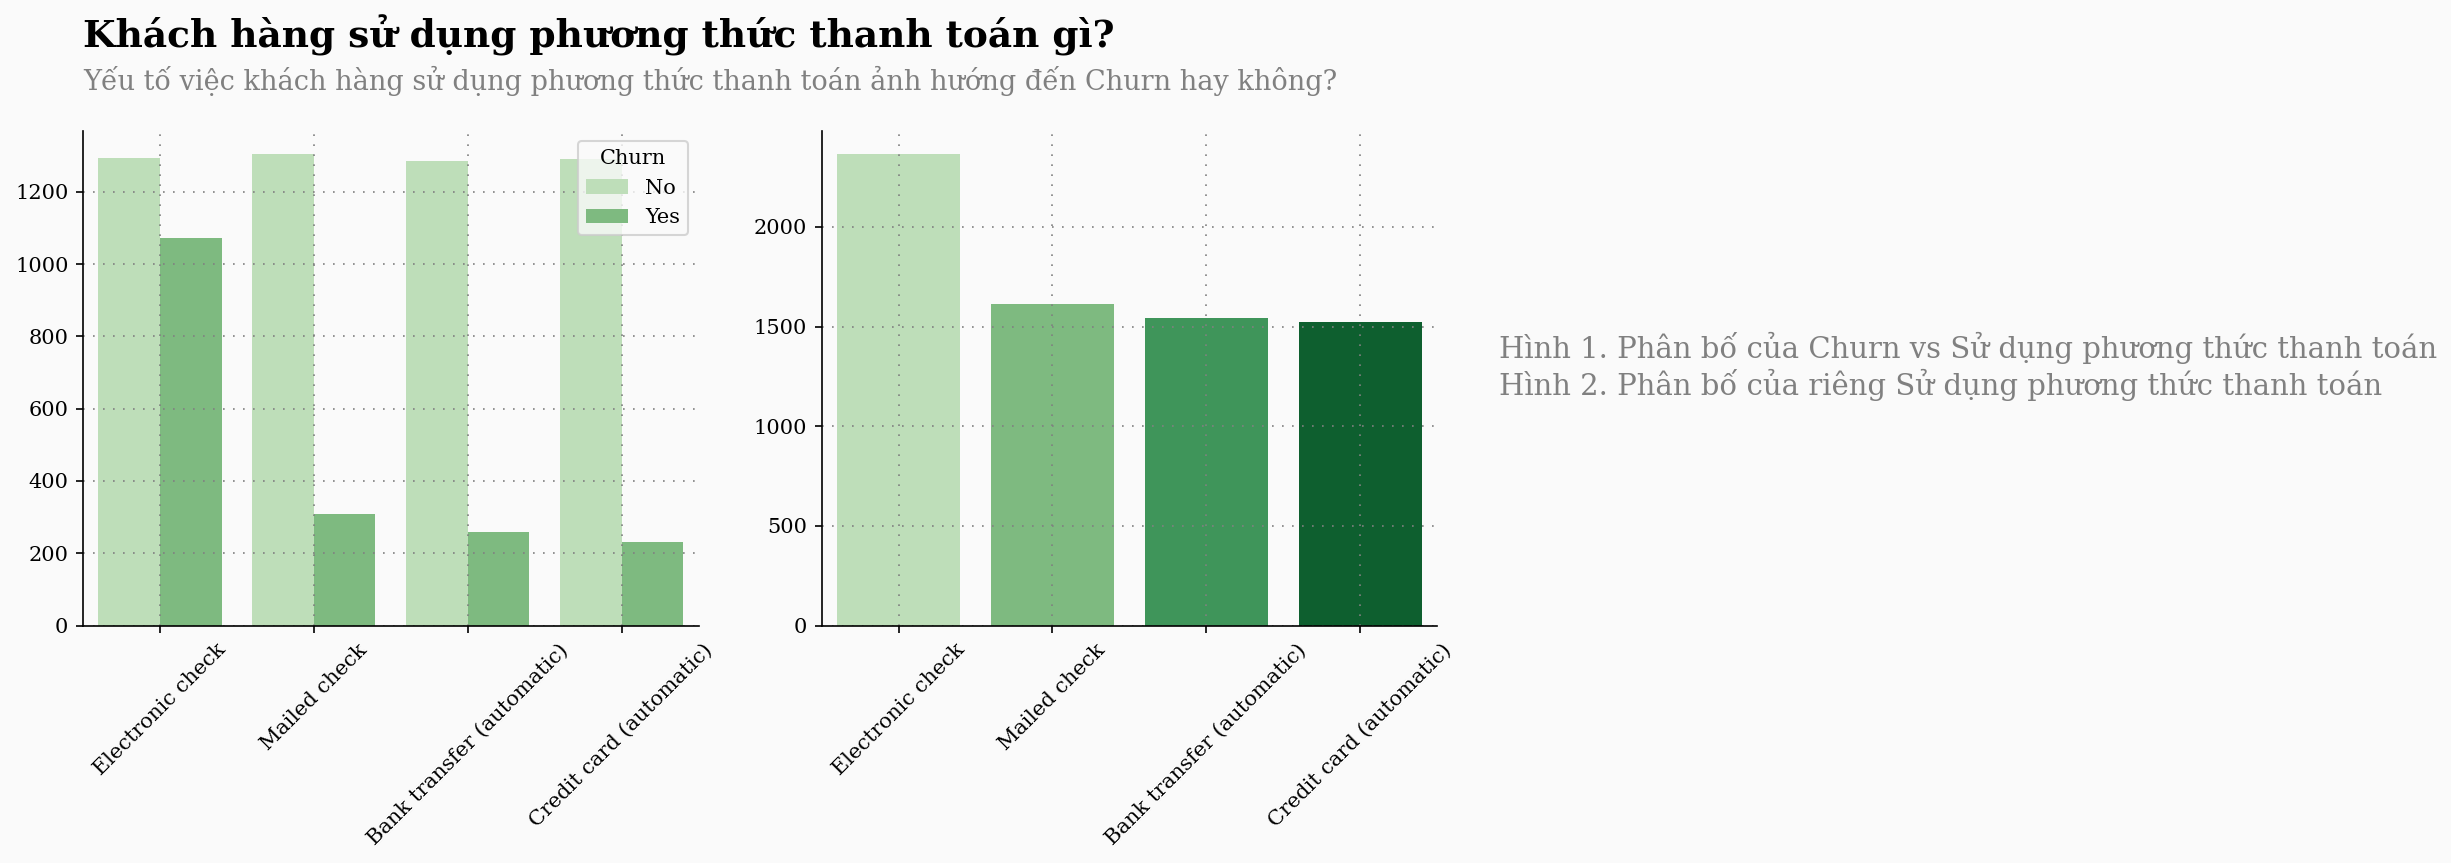

In [287]:
telco_contracts = telco[contracts]

fig = plt.figure(figsize=(18,15))
gs = fig.add_gridspec(3, 3)
gs.update(wspace=0.2, hspace=0.25)
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[0, 2])


for s in ["right", "top"]:
    ax0.spines[s].set_visible(False)
    ax1.spines[s].set_visible(False)



sns.countplot(ax=ax1, x=telco_contracts['PaymentMethod'], palette=palette)
sns.countplot(ax=ax0, x=telco_contracts['PaymentMethod'], hue=telco['Churn'], palette=palette)



Xstart, Xend = ax0.get_xlim()
Ystart, Yend = ax0.get_ylim()

ax0.set_ylim([0,Yend])
ax0.text(Xstart,Yend+(Yend*0.15), "Khách hàng sử dụng phương thức thanh toán gì?", fontsize=18, ha="left", va="bottom", weight="bold")
ax0.text(Xstart,Yend+(Yend*0.13), "Yếu tố việc khách hàng sử dụng phương thức thanh toán ảnh hướng đến Churn hay không?", color="gray",
fontsize=13, ha="left", va="top")

ax0.set_xlabel("")
ax0.set_ylabel("")
ax0.tick_params(axis='x', rotation=45)
ax1.set_xlabel("")
ax1.set_ylabel("")
ax1.tick_params(axis='x', rotation=45)

ax0.grid(which='major', axis='x', zorder=0, color='gray', linestyle=':', dashes=(1,5))
ax0.grid(color='gray', linestyle=':', axis='y', zorder=0,  dashes=(1,5))
ax1.grid(which='major', axis='x', zorder=0, color='gray', linestyle=':', dashes=(1,5))
ax1.grid(color='gray', linestyle=':', axis='y', zorder=0,  dashes=(1,5))


ax2.axis('off')  # Ẩn trục
ax2.text(-0.1, 0.4,
             "Hình 1. Phân bố của Churn vs Sử dụng phương thức thanh toán\n"
             "Hình 2. Phân bố của riêng Sử dụng phương thức thanh toán\n",
             fontsize=14,  color="gray")


plt.show()

**Nhận xét**

Có 4 nhóm đáng chú ý trong đặc trưng này:

- *Thanh toán qua điện*: Nhóm này có nhiều mẫu nhấy và tỉ lệ rời bỏ cũng nhiefu nhất trong bảng
- *Thanh toán qua mail*: Nhóm nhiều tương đối nhiều hơn so với 2 nhóm cuối nhưng rất ít
- *Thanh toán qua ngân hàng:* Nhóm này cũng xêm xêm với nhóm trên và nhóm cuối
- *Thanh toán bằng thẻ tín dụng:* Nhóm này cũng không có gì đặc biệt

**Tóm lại**

Có nhóm thanh toán qua điện thì chiếm nhiều nhất phân bố và cả tỉ lệ rời bỏ cũng nhiều nhất là đến từ nhóm này, 3 nhóm còn lại có  phân bố và biểu đồ bằng nhau và tỉ lệ phân bố rời bỏ cũng tương đối giống nhau khách hàng không rời bỏ vẫn nhiều hơn

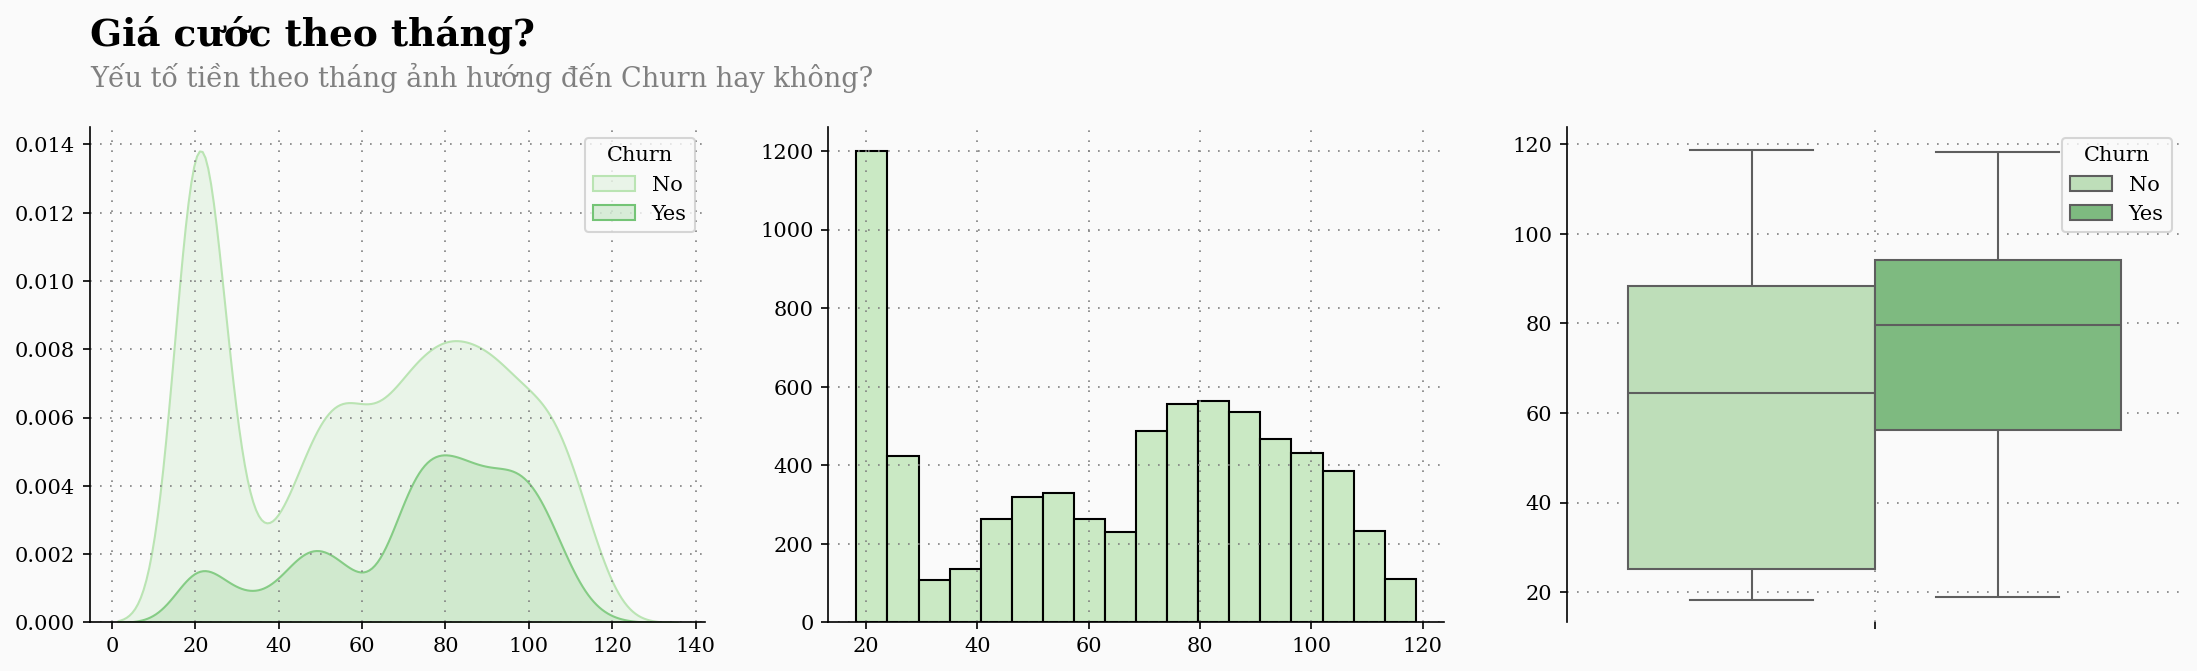

In [288]:
telco_contracts = telco[contracts]

fig = plt.figure(figsize=(18,15))
gs = fig.add_gridspec(3, 3)
gs.update(wspace=0.2, hspace=0.25)
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[0, 2])


for s in ["right", "top"]:
    ax0.spines[s].set_visible(False)
    ax1.spines[s].set_visible(False)

for s in ["right", "top", "bottom"]:
    ax2.spines[s].set_visible(False)

sns.kdeplot(ax=ax0, x=telco_contracts['MonthlyCharges'], hue=telco['Churn'], palette=palette, shade=True)
sns.histplot(ax=ax1, x=telco_contracts['MonthlyCharges'], color='#bae4b3')
sns.boxplot(ax=ax2, y=telco_contracts['MonthlyCharges'],hue=telco['Churn'], palette=palette)



Xstart, Xend = ax0.get_xlim()
Ystart, Yend = ax0.get_ylim()

ax0.set_ylim([0,Yend])
ax0.text(Xstart,Yend+(Yend*0.15), "Giá cước theo tháng?", fontsize=18, ha="left", va="bottom", weight="bold")
ax0.text(Xstart,Yend+(Yend*0.13), "Yếu tố tiền theo tháng ảnh hướng đến Churn hay không?", color="gray",
fontsize=13, ha="left", va="top")

ax0.set_xlabel("")
ax0.set_ylabel("")
ax1.set_xlabel("")
ax1.set_ylabel("")
ax2.set_xlabel("")
ax2.set_ylabel("")


ax0.grid(which='major', axis='x', zorder=0, color='gray', linestyle=':', dashes=(1,5))
ax0.grid(color='gray', linestyle=':', axis='y', zorder=0,  dashes=(1,5))
ax1.grid(which='major', axis='x', zorder=0, color='gray', linestyle=':', dashes=(1,5))
ax1.grid(color='gray', linestyle=':', axis='y', zorder=0,  dashes=(1,5))
ax2.grid(which='major', axis='x', zorder=0, color='gray', linestyle=':', dashes=(1,5))
ax2.grid(color='gray', linestyle=':', axis='y', zorder=0,  dashes=(1,5))

plt.show()

**Nhận xét**

Tiền thanh toán của phân bố nhiều ở mức 20 và từ 80 đến 100

**Với các nhóm**

- *Rời bỏ:* Đa số nằm ở mức phí thanh toán từ 80 đếm 100 (dươc xem là mức phí trên trung bình) có thể thấy mức phí trung bình của nhóm rời bỏ nhiều hơn là nhóm không rời bỏ

- *Không rời bỏ:* Đa số nằm ở mức phí rẻ và thấp có thể quan sát thấy ở biểu đồ đầu tiên

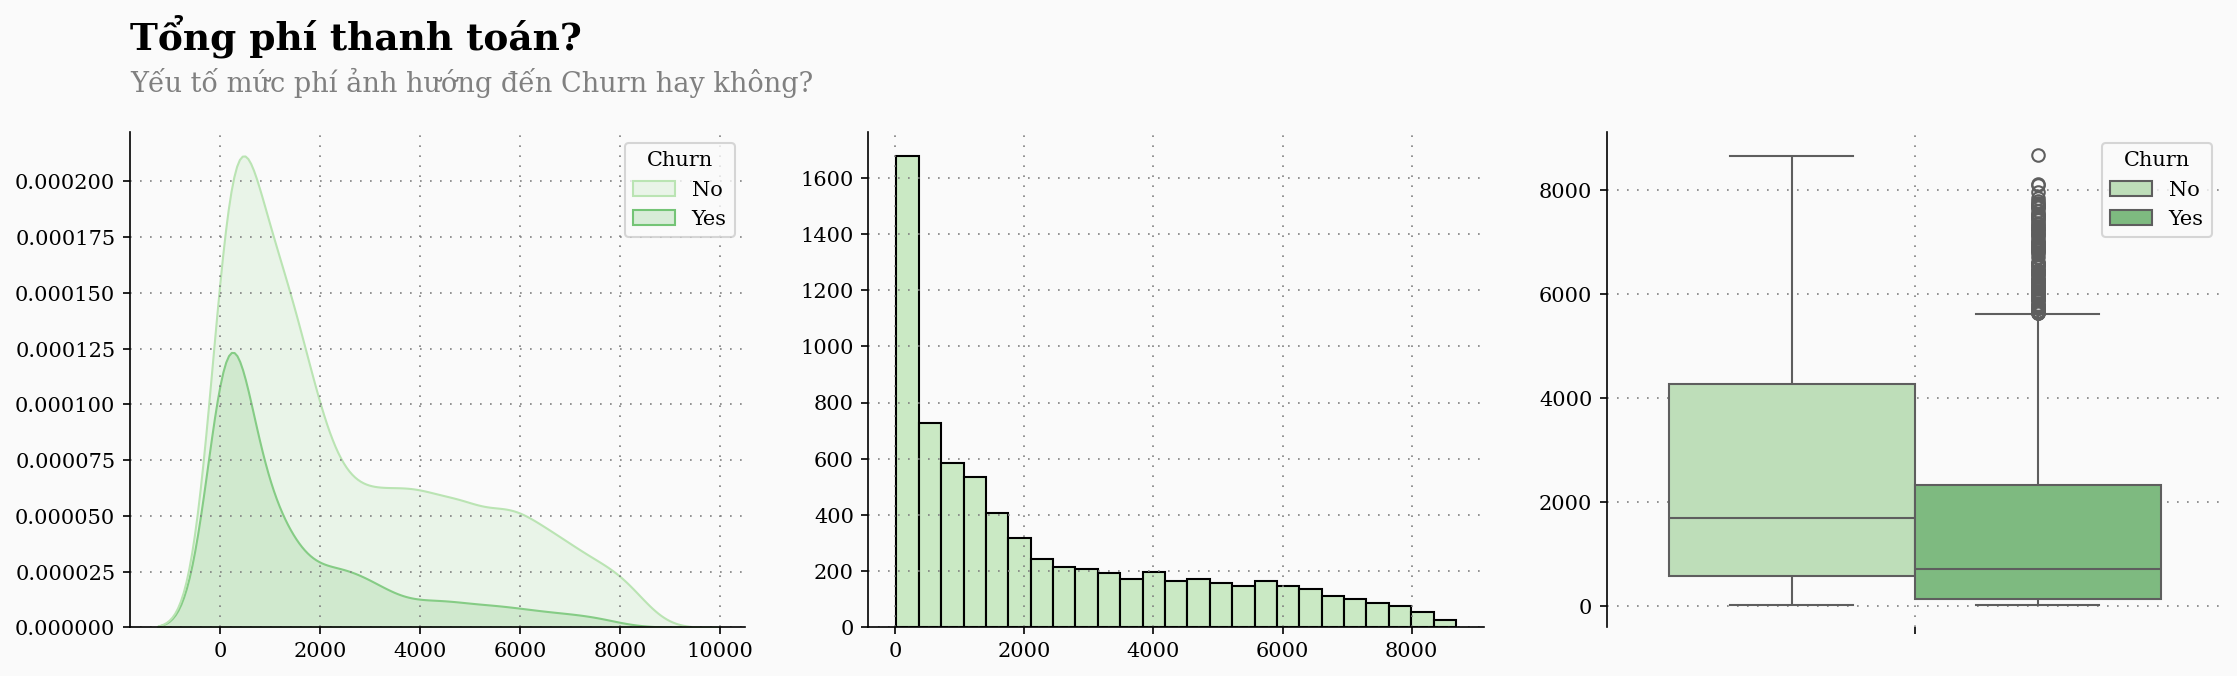

In [289]:
telco_contracts = telco[contracts]

# Chuyển vè đúng kiểu dữ liệu
telco_contracts['TotalCharges'] = pd.to_numeric(telco_contracts['TotalCharges'], errors='coerce')
telco_contracts = telco_contracts.dropna(subset=['TotalCharges'])


fig = plt.figure(figsize=(18,15))
gs = fig.add_gridspec(3, 3)
gs.update(wspace=0.2, hspace=0.25)
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[0, 2])


for s in ["right", "top"]:
    ax0.spines[s].set_visible(False)
    ax1.spines[s].set_visible(False)

for s in ["right", "top", "bottom"]:
    ax2.spines[s].set_visible(False)

sns.kdeplot(ax=ax0, x=telco_contracts['TotalCharges'], hue=telco['Churn'], palette=palette, shade=True)
sns.histplot(ax=ax1, x=telco_contracts['TotalCharges'], color='#bae4b3')
sns.boxplot(ax=ax2, y=telco_contracts['TotalCharges'],hue=telco['Churn'], palette=palette)



Xstart, Xend = ax0.get_xlim()
Ystart, Yend = ax0.get_ylim()

ax0.set_ylim([0,Yend])
ax0.text(Xstart,Yend+(Yend*0.15), "Tổng phí thanh toán?", fontsize=18, ha="left", va="bottom", weight="bold")
ax0.text(Xstart,Yend+(Yend*0.13), "Yếu tố mức phí ảnh hướng đến Churn hay không?", color="gray",
fontsize=13, ha="left", va="top")

ax0.set_xlabel("")
ax0.set_ylabel("")
ax1.set_xlabel("")
ax1.set_ylabel("")
ax2.set_xlabel("")
ax2.set_ylabel("")


ax0.grid(which='major', axis='x', zorder=0, color='gray', linestyle=':', dashes=(1,5))
ax0.grid(color='gray', linestyle=':', axis='y', zorder=0,  dashes=(1,5))
ax1.grid(which='major', axis='x', zorder=0, color='gray', linestyle=':', dashes=(1,5))
ax1.grid(color='gray', linestyle=':', axis='y', zorder=0,  dashes=(1,5))
ax2.grid(which='major', axis='x', zorder=0, color='gray', linestyle=':', dashes=(1,5))
ax2.grid(color='gray', linestyle=':', axis='y', zorder=0,  dashes=(1,5))

plt.show()

**Nhận xét**

Có thể thấy phân bố của tổng mức phí khá hỗn loạn do có thể chưa nhiều dữ liệu ngoại lai, trung bình tổng mức phí của nhóm rời bỏ lại ít hơn nhóm không rời bỏ. Trong phần này thì nhóm rời bỏ cho dù đã có mức phí tương đối nhưng họ vẫn có lý do để rời bỏ

## **🔍 Correlation Analysis (Phân tích quan hệ)**

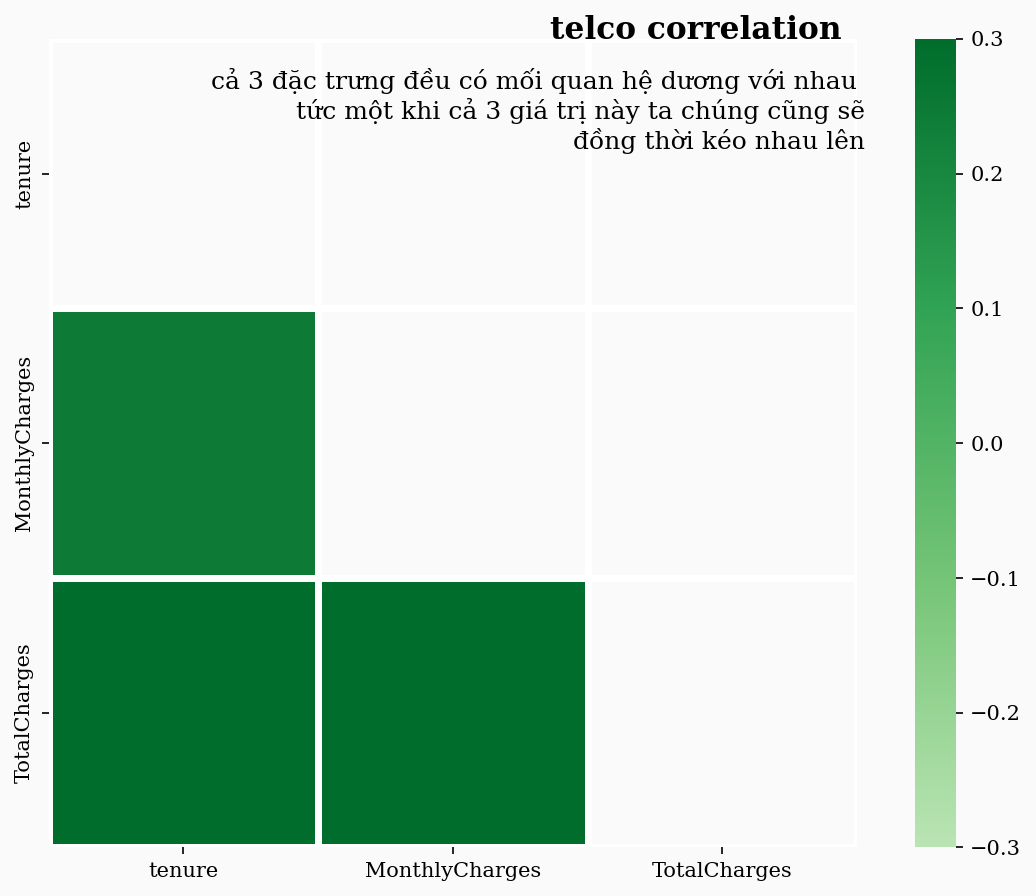

In [290]:
import matplotlib.colors

cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ["#bae4b3", "#74c476", "#31a354", "#006d2c"])

telco['TotalCharges'] = pd.to_numeric(telco['TotalCharges'], errors='coerce')
telco['TotalCharges'] = telco['TotalCharges'].fillna(0)

# Với đặc trưng liên tục

num_telco_feature =  ['tenure', 'MonthlyCharges', 'TotalCharges']


telco_num = telco[num_telco_feature]

corr_matrix = telco_num.corr()

mask = np.zeros_like(corr_matrix, dtype=np.bool)
mask[np.triu_indices_from(mask)] = True
fig, ax = plt.subplots(figsize=(10, 7))
fig.text(.54,.88,'telco correlation', fontweight='bold',fontsize=15)
fig.text(.75,.75,
            '''
            cả 3 đặc trưng đều có mối quan hệ dương với nhau
            tức một khi cả 3 giá trị này ta chúng cũng sẽ
            đồng thời kéo nhau lên
             ''', fontfamily='serif',fontsize=12,ha='right')
pl = sns.heatmap(corr_matrix, mask=mask, cmap=cmap, vmax=.3, vmin=-.3, center=0, square=True, linewidths=2.5)

plt.show()

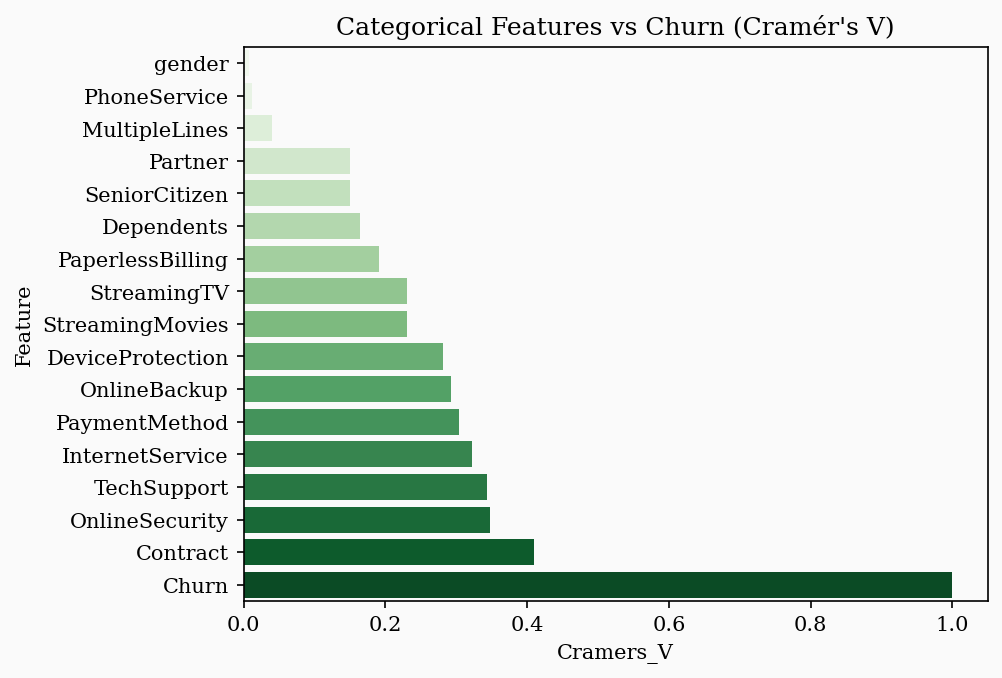

In [294]:
from scipy.stats import chi2_contingency

# telco = telco.drop(columns=['customerID'])
# Ép kiểu về phân loại
telco['SeniorCitizen'] = telco['SeniorCitizen'].astype('object')
# Chọn đặc trưng phân loại
telco_cate = telco.select_dtypes(include='object')
# Lựa đặc trưng phân loại
cate_telco_feature = telco_cate.columns


def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    k = min(ct.shape) - 1
    return np.sqrt(chi2 / (n * k))

results = []

for col in cate_telco_feature:
    v = cramers_v(telco_cate[col], telco['Churn'])
    results.append((col, v))

cramers_df = pd.DataFrame(results, columns=['Feature', 'Cramers_V'])
cramers_df = cramers_df.sort_values(by='Cramers_V')

sns.barplot(data=cramers_df, x='Cramers_V', y='Feature', palette='Greens')
plt.title("Categorical Features vs Churn (Cramér's V)")
plt.show()

Sử dụng kiểm định giả thuyết để quan sát sự phụ thuộc mối tương quan giữa các biến phân loại với biến mục tiêu

## **✅ EDA Summary (Tóm tắt Khám phá dữ liệu)**